# FInal Project

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

## Packages

In [1]:
library(fst)
library(highfrequency)
library(xts)
library(rugarch)
library(forecast)
library(zoo)
library(ggplot2)
library(tidyr)

Warning message:
"package 'fst' was built under R version 4.5.3"
Warning message:
"package 'highfrequency' was built under R version 4.5.3"
Warning message:
"package 'xts' was built under R version 4.5.2"
Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Warning message:
"package 'rugarch' was built under R version 4.5.2"
Loading required package: parallel

Warning message:
"package 'forecast' was built under R version 4.5.2"
Warning message:
"package 'tidyr' was built under R version 4.5.2"


## Loading Data

In [2]:
data <- load("data_project/26.RData")   # loads the .RData file into the environment
head(data)                               # shows the name(s) of objects stored in the file
asset_data <- get(data[1])              # retrieves the first object by name
head(asset_data)                        

[1] "amat"

                    ret         RV        RV_p        RV_n          RS       RK
2010-01-05  0.010600358 0.01537440 0.010802724 0.010939525  0.22027109 4.607369
2010-01-06 -0.002112787 0.01482381 0.011268814 0.009631161  0.58156996 3.443174
2010-01-07 -0.004239012 0.01455766 0.009431595 0.011089210 -0.53822008 4.062540
2010-01-08  0.006351798 0.01627584 0.012371915 0.010575383  0.02566745 4.681865
2010-01-11  0.041973644 0.02193678 0.013281618 0.017459120 -1.15919678 5.918139
2010-01-12 -0.006089911 0.02460140 0.014433799 0.019922207 -0.60888995 3.864707

"amat" is the ticker symbol for Applied Materials, Inc. (AMAT) - a large US semiconductor equipment company traded on NASDAQ. So our asset (#26) is the daily realized volatility data for Applied Materials stock, starting from January 2010.

In [4]:
n_obs           <- nrow(asset_data)
window_len      <- 750
n_out_of_sample <- n_obs - window_len
idx             <- as.Date(index(asset_data))
oos_dates       <- tail(idx, n_out_of_sample)

# Apply the zero-return fix and scale by 100
safe_ret <- as.numeric(asset_data$ret)
safe_ret[safe_ret == 0] <- 1e-6
returns_xts <- xts(safe_ret * 100, order.by = idx)
rv_xts      <- xts(as.numeric(asset_data$RV) * 100, order.by = idx)

# Specifications
spec_standard <- ugarchspec(
  variance.model     = list(model = "sGARCH",   garchOrder = c(1, 1)),
  mean.model         = list(armaOrder = c(0, 0), include.mean = FALSE),
  distribution.model = "norm"
)

spec_real <- ugarchspec(
  variance.model     = list(model = "realGARCH", garchOrder = c(1, 1)),
  mean.model         = list(armaOrder = c(0, 0), include.mean = FALSE),
  distribution.model = "norm"
)

# =============================================================================
# 2. INITIALIZE PARALLEL CLUSTER (The key to speed)
# =============================================================================
# Detect available cores and leave 1 free for background OS tasks
no_cores <- detectCores() - 1  
cl <- makePSOCKcluster(no_cores)
cat("Running parallel cluster with", no_cores, "cores...\n")

# =============================================================================
# 3. sGARCH FORECASTS (Daily Refit, Parallel)
# =============================================================================
cat("Running sGARCH Moving...\n")
system.time({
  roll_std_mov <- ugarchroll(spec_standard, data = returns_xts, n.ahead = 1,
                             forecast.length = n_out_of_sample, 
                             refit.every = 1, refit.window = "moving", window.size = window_len,
                             solver = "hybrid", calculate.VaR = FALSE, cluster = cl)
})

cat("Running sGARCH Expanding...\n")
system.time({
  roll_std_exp <- ugarchroll(spec_standard, data = returns_xts, n.ahead = 1,
                             forecast.length = n_out_of_sample, 
                             refit.every = 1, refit.window = "recursive", window.size = window_len,
                             solver = "hybrid", calculate.VaR = FALSE, cluster = cl)
})

# =============================================================================
# 4. realGARCH FORECASTS (Daily Refit, Parallel)
# =============================================================================
# Pass realizedVol directly into ugarchroll. The hybrid solver ensures it 
# won't instantly fail and discard all forecasts if one window acts up.
cat("Running realGARCH Moving...\n")
system.time({
  roll_real_mov <- ugarchroll(spec_real, data = returns_xts, realizedVol = rv_xts, n.ahead = 1,
                              forecast.length = n_out_of_sample, 
                              refit.every = 1, refit.window = "moving", window.size = window_len,
                              solver = "hybrid", calculate.VaR = FALSE, cluster = cl)
})

cat("Running realGARCH Expanding...\n")
system.time({
  roll_real_exp <- ugarchroll(spec_real, data = returns_xts, realizedVol = rv_xts, n.ahead = 1,
                              forecast.length = n_out_of_sample, 
                              refit.every = 1, refit.window = "recursive", window.size = window_len,
                              solver = "hybrid", calculate.VaR = FALSE, cluster = cl)
})

# =============================================================================
# 5. SHUT DOWN CLUSTER
# =============================================================================
stopCluster(cl)

# =============================================================================
# 6. EXTRACT FORECASTS AND PLOT
# =============================================================================
f_sgarch_mov <- xts(roll_std_mov@forecast$density$Sigma / 100, order.by = oos_dates)
f_sgarch_exp <- xts(roll_std_exp@forecast$density$Sigma / 100, order.by = oos_dates)
f_real_mov   <- xts(roll_real_mov@forecast$density$Sigma / 100, order.by = oos_dates)
f_real_exp   <- xts(roll_real_exp@forecast$density$Sigma / 100, order.by = oos_dates)

colnames(f_sgarch_mov) <- "sGARCH_Moving";    colnames(f_sgarch_exp) <- "sGARCH_Expanding"
colnames(f_real_mov)   <- "realGARCH_Moving"; colnames(f_real_exp)   <- "realGARCH_Expanding"

actual_rv_oos <- xts(as.numeric(tail(asset_data$RV, n_out_of_sample)), order.by = oos_dates)
colnames(actual_rv_oos) <- "True_RV"
plot_data <- merge(actual_rv_oos, f_sgarch_mov, f_sgarch_exp, f_real_mov, f_real_exp)

par(mfrow = c(2, 1), mar = c(3, 4, 2, 1))
mov_cols <- intersect(c("True_RV", "sGARCH_Moving", "realGARCH_Moving"), colnames(plot_data))
plot.zoo(plot_data[, mov_cols], screens = 1, col = c("black", "red", "blue")[seq_along(mov_cols)],
         main = "Moving Window: sGARCH vs realGARCH (Daily Refit)", ylab = "Volatility", xlab = "", lwd = 1.3)
legend("topleft", legend = mov_cols, col = c("black", "red", "blue")[seq_along(mov_cols)], lty = 1, cex = 0.8)

exp_cols <- intersect(c("True_RV", "sGARCH_Expanding", "realGARCH_Expanding"), colnames(plot_data))
plot.zoo(plot_data[, exp_cols], screens = 1, col = c("black", "darkorange", "purple")[seq_along(exp_cols)],
         main = "Expanding Window: sGARCH vs realGARCH (Daily Refit)", ylab = "Volatility", xlab = "Date", lwd = 1.3)
legend("topleft", legend = exp_cols, col = c("black", "darkorange", "purple")[seq_along(exp_cols)], lty = 1, cex = 0.8)
par(mfrow = c(1, 1))

Running parallel cluster with 7 cores...
Running sGARCH Moving...


   user  system elapsed 
   0.31    0.09   42.10 

Running sGARCH Expanding...


   user  system elapsed 
   0.28    0.02   38.06 

Running realGARCH Moving...


   user  system elapsed 
   0.33    0.06  244.98 

Running realGARCH Expanding...


Warning message in .rollfdensity.real(spec = spec, data = data, n.ahead = n.ahead, :
"
non-converged estimation windows present...resubsmit object with different solver parameters..."


   user  system elapsed 
   0.14    0.14  381.48 

ERROR: Error in `colnames<-`(`*tmp*`, value = "realGARCH_Expanding"): attempt to set 'colnames' on an object with less than two dimensions


## Exploratory analysis

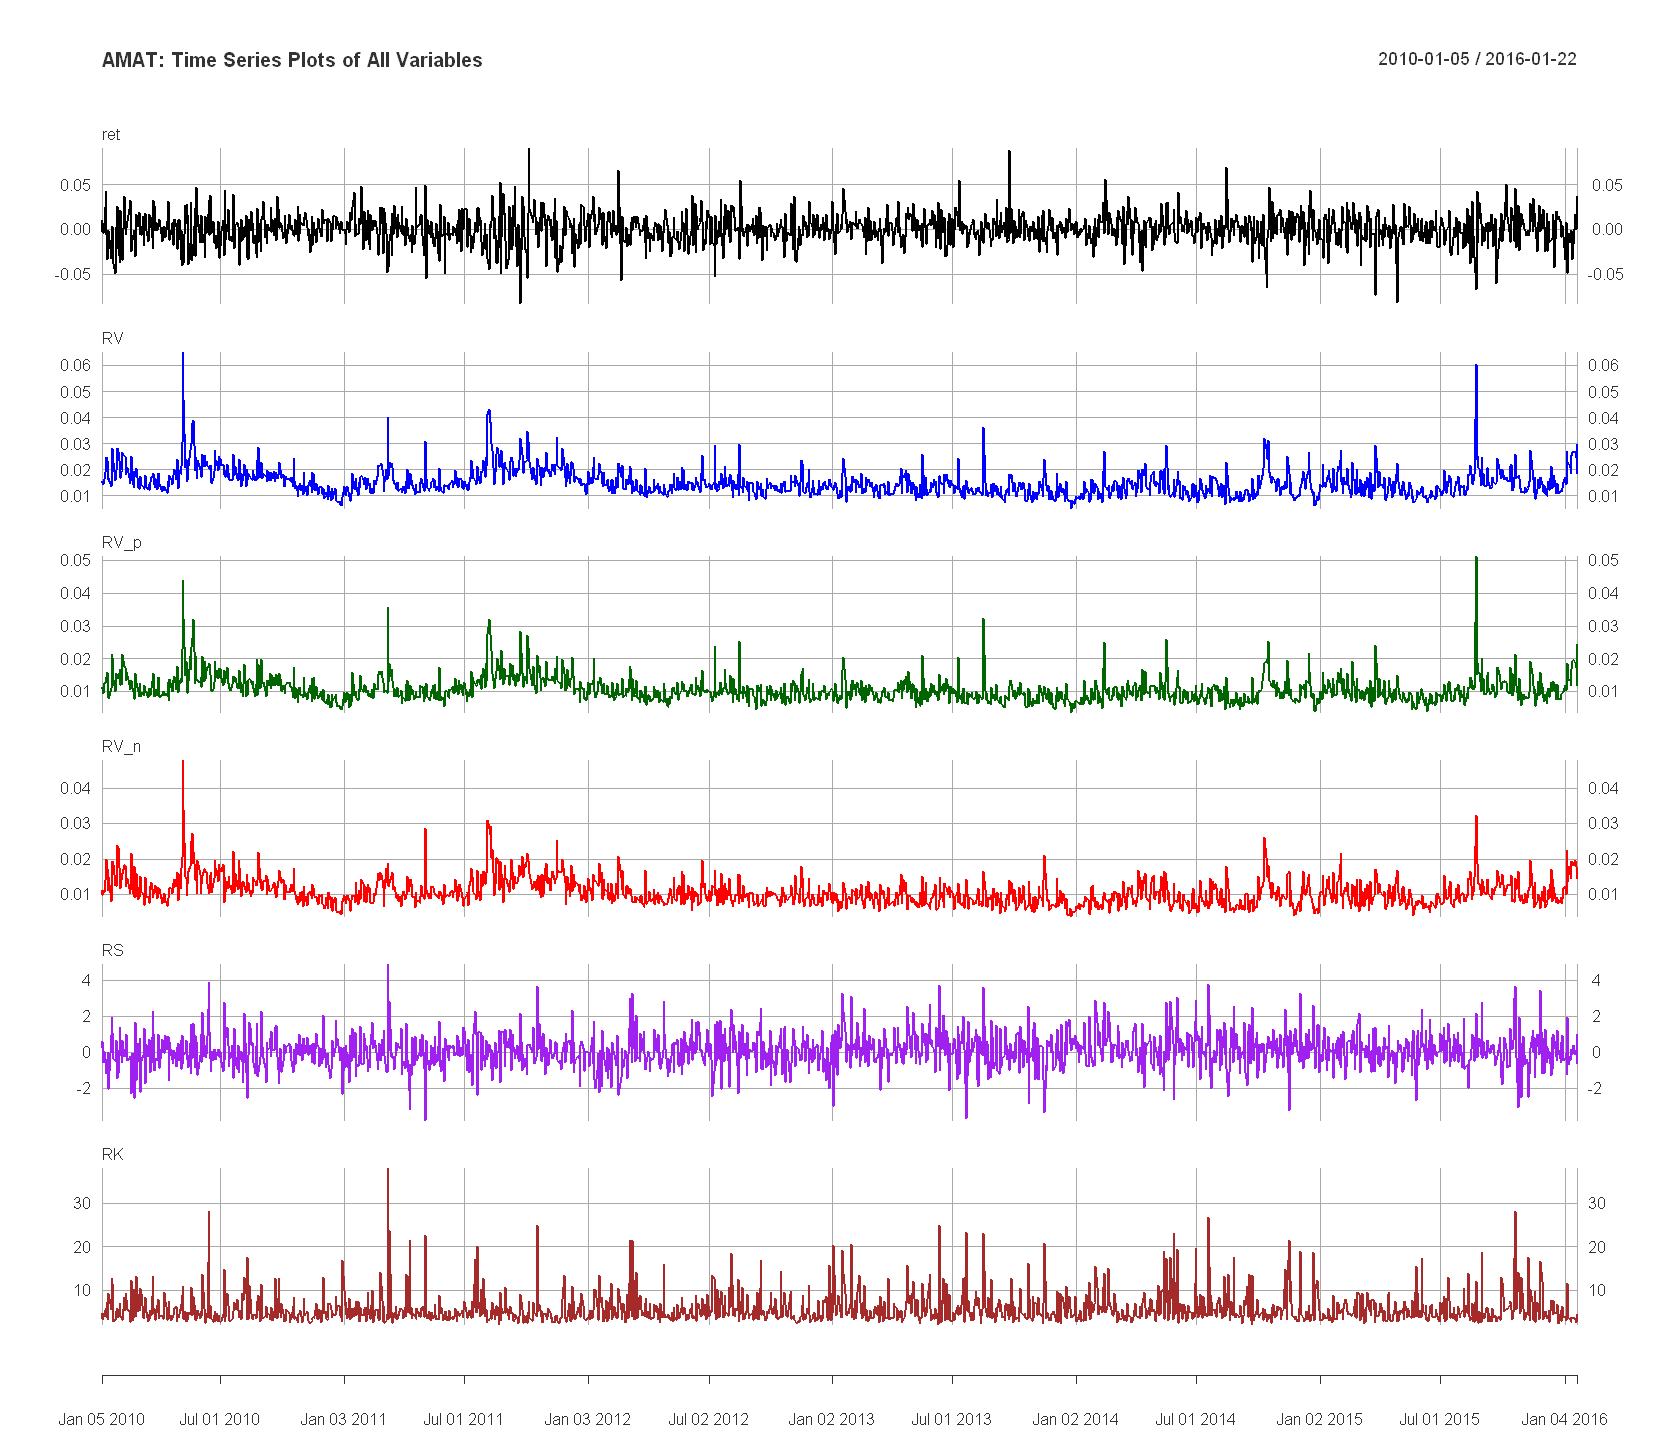

In [3]:
options(repr.plot.width = 14, repr.plot.height = 12)
plot.xts(asset_data, 
         multi.panel = TRUE, 
         yaxis.same = FALSE,
         col = c("black", "blue", "darkgreen", "red", "purple", "brown"),
         main = "AMAT: Time Series Plots of All Variables")

In [4]:
# descriptive statistics
summary(coredata(asset_data)) # view the summary of all columns except the index column

      ret                   RV                RV_p               RV_n         
 Min.   :-0.0831897   Min.   :0.005378   Min.   :0.003804   Min.   :0.003802  
 1st Qu.:-0.0096931   1st Qu.:0.011861   1st Qu.:0.008198   1st Qu.:0.007937  
 Median : 0.0008695   Median :0.014288   Median :0.010081   Median :0.009841  
 Mean   : 0.0002284   Mean   :0.015212   Mean   :0.010768   Mean   :0.010558  
 3rd Qu.: 0.0106051   3rd Qu.:0.017221   3rd Qu.:0.012362   3rd Qu.:0.012405  
 Max.   : 0.0906058   Max.   :0.065073   Max.   :0.051231   Max.   :0.047888  
       RS                 RK        
 Min.   :-3.76626   Min.   : 2.237  
 1st Qu.:-0.48534   1st Qu.: 3.636  
 Median : 0.07282   Median : 4.607  
 Mean   : 0.10153   Mean   : 5.713  
 3rd Qu.: 0.62721   3rd Qu.: 6.383  
 Max.   : 4.86950   Max.   :37.962  

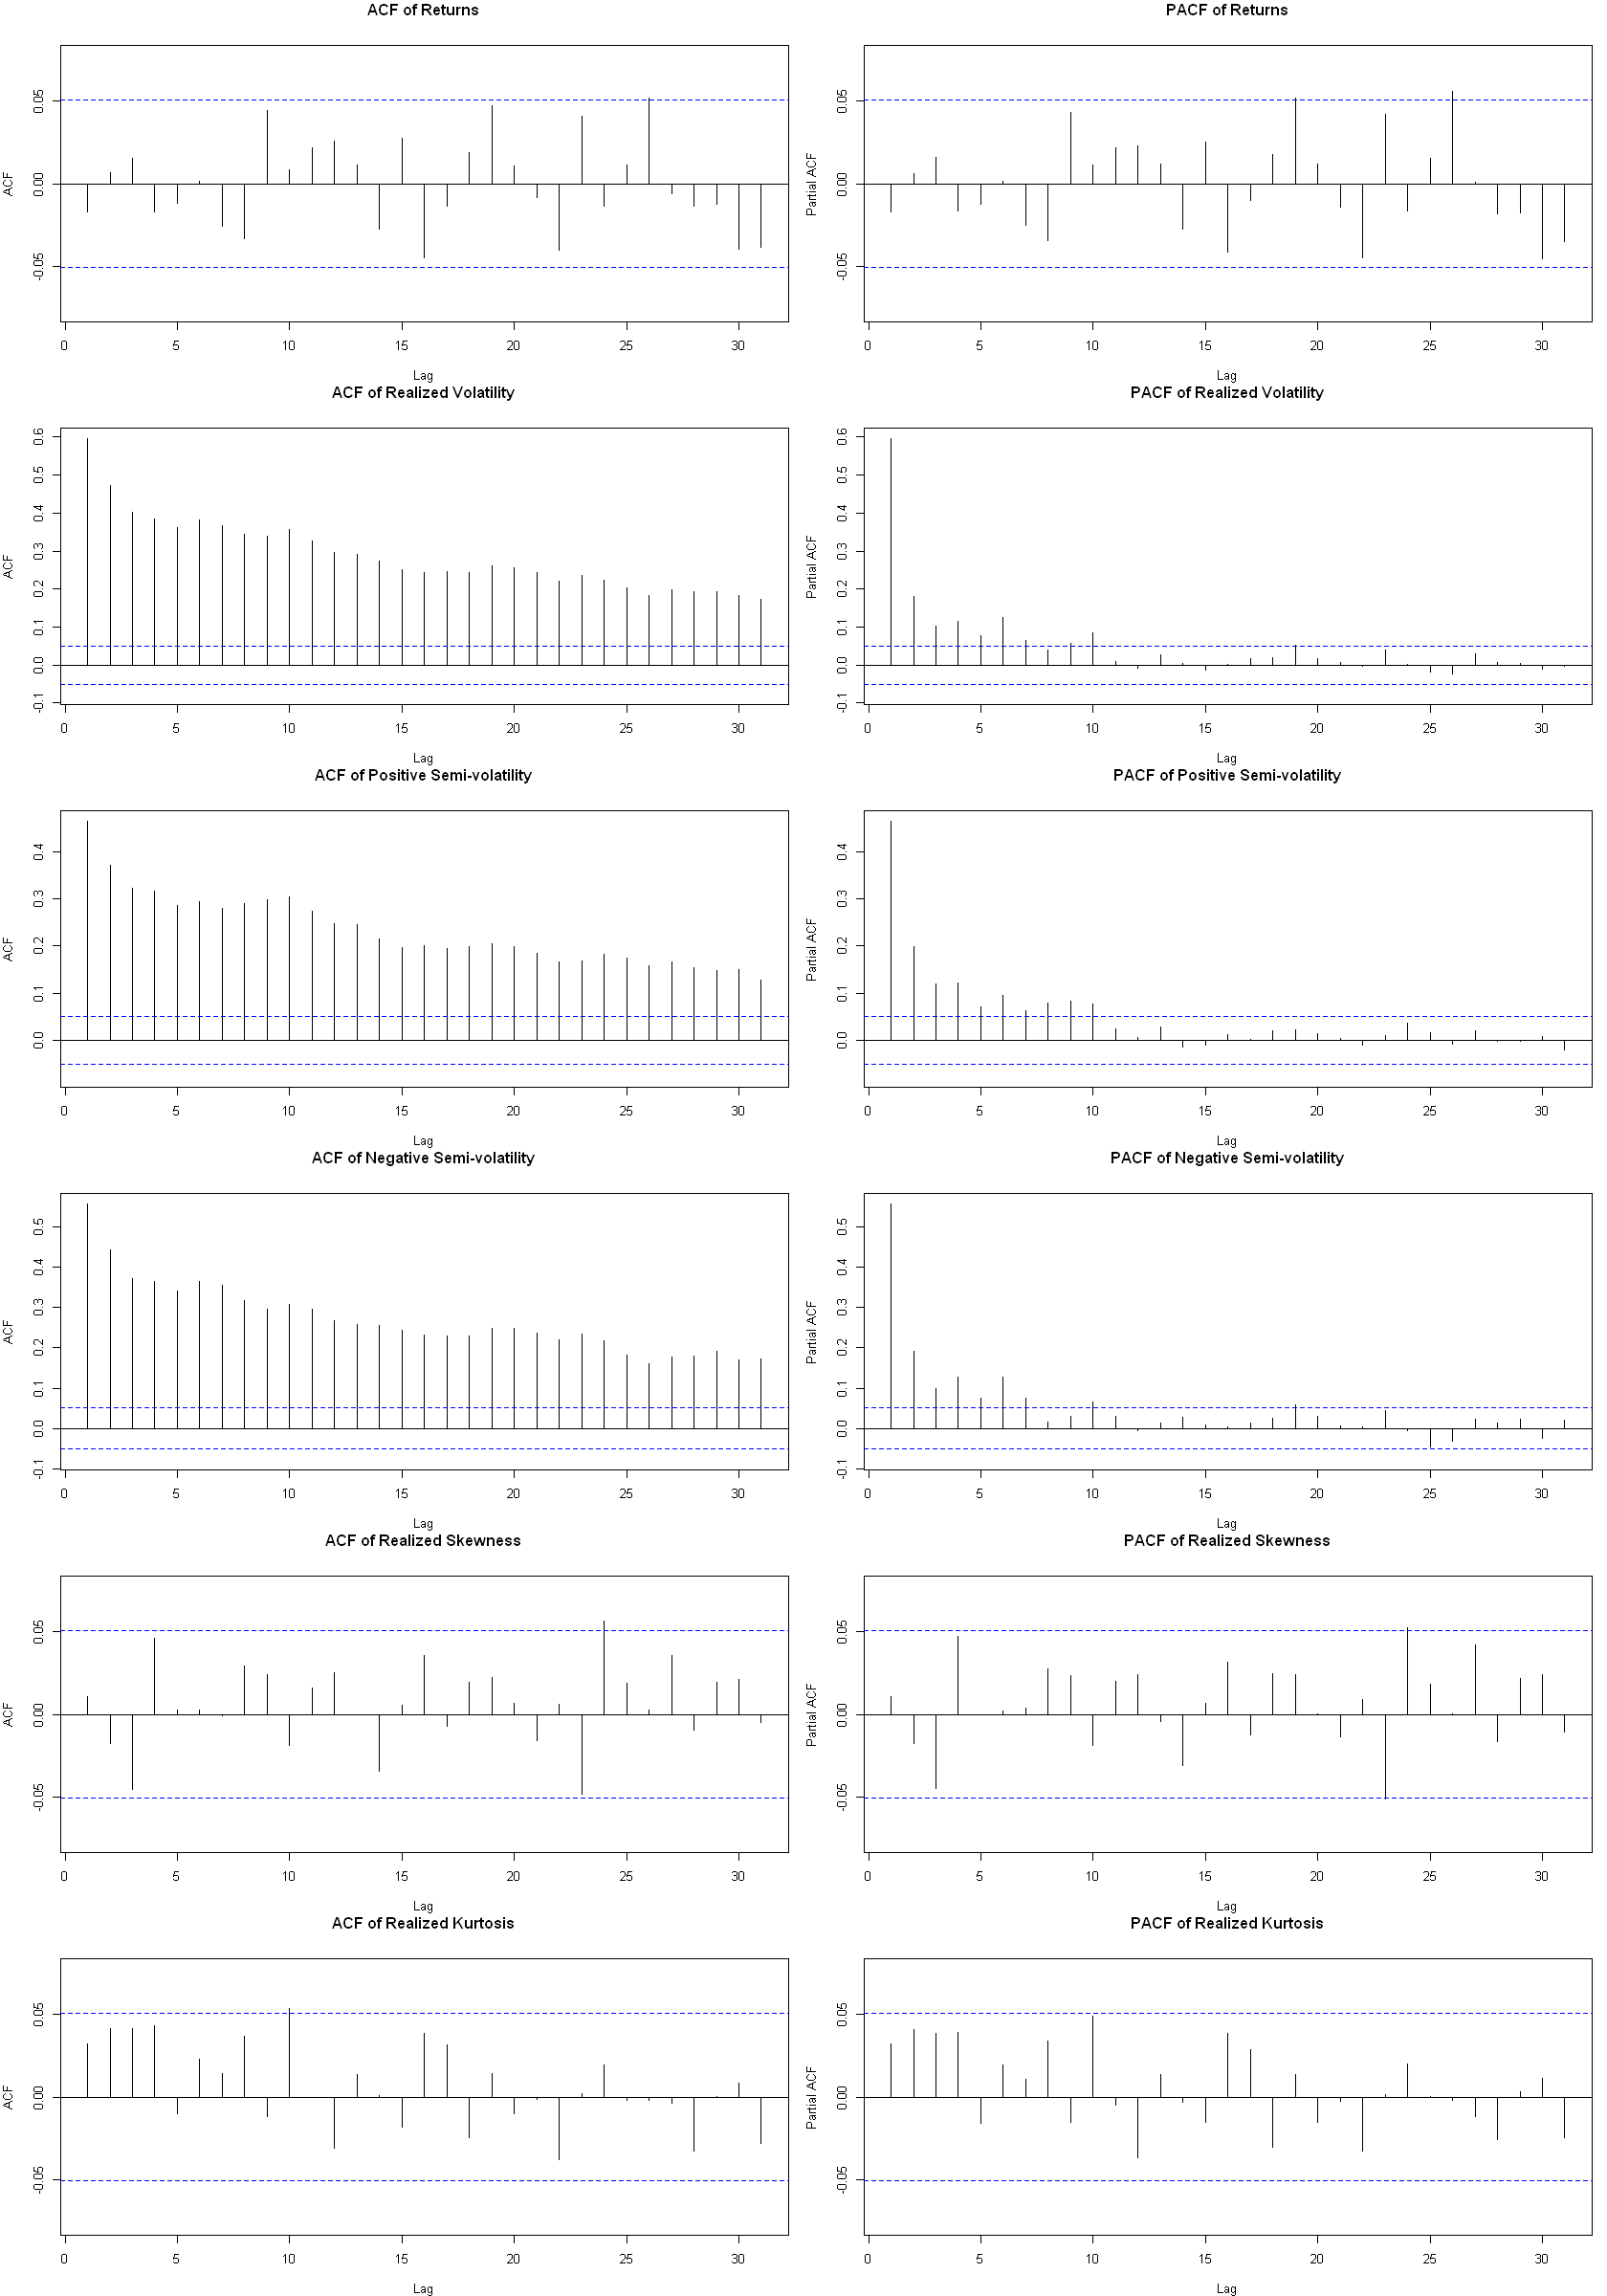

In [5]:
options(repr.plot.width = 14, repr.plot.height = 20)
par(mfrow = c(6, 2), mar = c(4, 4, 3, 1))

#ret
Acf(asset_data$ret, main = "ACF of Returns")
Pacf(asset_data$ret, main = "PACF of Returns")

#rv
Acf(asset_data$RV, main = "ACF of Realized Volatility")
Pacf(asset_data$RV, main = "PACF of Realized Volatility")

#rvp
Acf(asset_data$RV_p, main = "ACF of Positive Semi-volatility")
Pacf(asset_data$RV_p, main = "PACF of Positive Semi-volatility")

#rvn
Acf(asset_data$RV_n, main = "ACF of Negative Semi-volatility")
Pacf(asset_data$RV_n, main = "PACF of Negative Semi-volatility")
#rs
Acf(asset_data$RS, main = "ACF of Realized Skewness")
Pacf(asset_data$RS, main = "PACF of Realized Skewness")
#rk
Acf(asset_data$RK, main = "ACF of Realized Kurtosis")
Pacf(asset_data$RK, main = "PACF of Realized Kurtosis")


par(mfrow = c(1, 1))

The dataset covers 2010-01-05 to 2016-01-22, providing approximately 1,509 daily observations for AMAT. Each observation contains the daily log return and five realized measures computed from 5-minute intraday data.

### Returns (`ret`)

The time series plot shows daily log returns fluctuating around zero with no visible trend or drift throughout the entire sample. The distribution is roughly symmetric (mean ≈ 0.0002, median ≈ 0.0009), which we would expect for daily returns. The minimum and maximum correspond to single-day moves of -8.3% and +9.1% respectively, far larger than a normal distribution would imply, indicating that the returns have fatter tails than the normal distribution. Periods of larger swings are visually clustered — particularly around 2010–2011 and 2015–2016 — revealing the phenomenon of volatility clustering in equity returns.

The ACF and PACF of returns are almost entirely within the 95% confidence bands across all 32 lags, with only a few marginal crossings consistent with chance at the 5% level. This confirms that daily returns are serially uncorrelated, in line with the weak form of market efficiency: past returns carry no significant linear information about future returns.


### Realized Volatility (`RV`)

The time series of RV makes the volatility clustering visible in a much cleaner way than returns alone. RV oscillates around a baseline of approximately 0.014–0.015, with some sharp upward spikes — most prominent in early 2010 and again in 2015–2016. The distribution is clearly right-skewed: the mean (0.0152) exceeds the median (0.0143), and the maximum (0.0651) is more than 4× the median, reflecting the heavy right tail typical of realized volatility measures.

The ACF of RV starts at approximately 0.6 at lag 1 and decays very slowly, remaining statistically significant well beyond lag 30. This slow, gradual decay indicates high persistence, consistent with either long memory or near-unit-root dynamics. The PACF shows one dominant spike at lag 1 (~0.6), followed by a few smaller significant partial autocorrelations at lags 2–5, and then rapid decay toward zero. This combination — slowly decaying ACF with a sharp PACF cutoff — rules out a simple AR(1) and motivates richer models capable of capturing persistence across multiple horizons, most naturally the HAR model.

### Positive and Negative Semi-volatilities (`RV_p`, `RV_n`)

Both semi-volatility series closely mirror the shape of RV in the time series plot, which is expected by construction since $\text{RV}_t \approx \text{RV}^+_t + \text{RV}^-_t$. This is confirmed in the summary statistics: the means sum closely to the mean of RV ($0.0108 + 0.0106 \approx 0.0214$). On average, positive and negative intraday variation are nearly symmetric, though subtle asymmetries are visible during stress episodes — for instance, the early-2010 spike appears somewhat more pronounced in `RV_n`, suggesting a downside-driven event.

The ACF and PACF structures of both series are nearly identical to those of RV: slowly decaying ACF with significant autocorrelations through lag 30+, and a dominant PACF spike at lag 1 followed by rapid decay. This shared persistence structure is the motivation for the HAR-RS model, which decomposes RV into its positive and negative components to test whether intraday asymmetry carries incremental predictive content beyond total variation.

### Realized Skewness (`RS`)

In contrast to the volatility measures, RS fluctuates around zero with no visible persistence or clustering in the time series. The mean is slightly positive (0.10), indicating a marginal upward bias in intraday price moves on average, but the wide range (-3.77 to +4.87) and large IQR confirm high day-to-day variability.

The ACF and PACF of RS are almost entirely within the confidence bands — RS is close to white noise in its own dynamics. This is consistent with RS capturing the direction of intraday jumps, which is largely unpredictable from the past. Importantly, this does not make RS irrelevant as a predictor: in the HAR-RS and HAR-Moments models, today's skewness may still help forecast tomorrow's RV, even if past skewness cannot forecast future skewness.

### Realized Kurtosis (`RK`)

RK is always well above 3 throughout the sample — the mean is 5.71 and the median is 4.61 — confirming that intraday return distributions are fat-tailed every single day, not just during crises. Extreme values (up to 37.96) appear as isolated spikes in the time series, likely corresponding to earnings announcements or macro surprises, rather than as persistent regimes.

Like RS, the ACF and PACF of RK show no meaningful persistence — both are largely within the confidence bands across all lags. The day-to-day level of excess kurtosis is essentially unpredictable from its own past. As with RS, RK may nonetheless carry predictive value for future RV as a regressor in the HAR-Moments model, capturing the information content of extreme intraday moves for next-day volatility.

In [36]:
# Subset the data to find rows where 'ret' is exactly 0
zero_return_data <- asset_data[asset_data$ret == 0]

# Print the dates (the index of the xts object)
dates_with_zero_return <- index(zero_return_data)
print(dates_with_zero_return)

 [1] "2010-10-14" "2010-12-30" "2011-01-03" "2011-06-30" "2011-10-18"
 [6] "2012-06-14" "2012-07-27" "2012-12-18" "2012-12-31" "2013-07-18"
[11] "2013-07-19" "2013-09-13" "2014-02-27" "2014-12-05" "2015-04-13"
[16] "2016-01-20"


In [37]:
# Extract and print just the RV column for those specific dates
rv_on_zero_days <- asset_data[dates_with_zero_return, "RV"]
print(rv_on_zero_days)

                    RV
2010-10-14 0.015521227
2010-12-30 0.006438096
2011-01-03 0.013812577
2011-06-30 0.012634222
2011-10-18 0.024294995
2012-06-14 0.015736906
2012-07-27 0.013774829
2012-12-18 0.012361719
2012-12-31 0.013746353
2013-07-18 0.014008635
2013-07-19 0.008613411
2013-09-13 0.008901869
2014-02-27 0.011775913
2014-12-05 0.014391033
2015-04-13 0.010596413
2016-01-20 0.024883860


## In-Sample models

### data preparation

In [6]:
#rv lagged daily
RV_1 <- lag(asset_data$RV, 1)
#rolling weekly and monthly averages
RV_5 <- rollmean(RV_1, k = 5, fill = NA, align = "right")
RV_22 <- rollmean(RV_1, k = 22, fill = NA, align = "right")

In [7]:
#kurtosis and skeweness daily lags
RS_1 <- lag(asset_data$RS, 1)
RK_1 <- lag(asset_data$RK, 1)

In [8]:
#create dataset we will use for the regressions
har_data <- merge(asset_data$RV, RV_1, RV_5, RV_22, RS_1, RK_1)
colnames(har_data) <- c("RV", "RV_1", "RV_5", "RV_22", "RS_1", "RK_1")
har_data <- na.omit(har_data)
head(har_data)

                   RV       RV_1       RV_5      RV_22        RS_1     RK_1
2010-02-05 0.02657759 0.01996497 0.02066632 0.02003278 -0.58567243 3.312116
2010-02-08 0.02530772 0.02657759 0.02055692 0.02054201  0.66537303 3.085123
2010-02-09 0.02521336 0.02530772 0.02156734 0.02101855 -0.21735552 8.374643
2010-02-10 0.01815253 0.02521336 0.02325089 0.02150290 -0.05696237 5.464957
2010-02-11 0.02047238 0.01815253 0.02304323 0.02158821  0.82791989 9.356345
2010-02-12 0.02081424 0.02047238 0.02314472 0.02152164  0.98267322 7.889675

### Models

In [9]:
fit_ar1 <- lm(RV ~ RV_1, data = har_data)
summary(fit_ar1)


Call:
lm(formula = RV ~ RV_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.017874 -0.002509 -0.000494  0.001867  0.043466 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0061619  0.0003353   18.38   <2e-16 ***
RV_1        0.5929793  0.0209537   28.30   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.004172 on 1476 degrees of freedom
Multiple R-squared:  0.3517,	Adjusted R-squared:  0.3513 
F-statistic: 800.9 on 1 and 1476 DF,  p-value: < 2.2e-16


In [10]:
fit_har <- lm(RV ~ RV_1 + RV_5 + RV_22, data = har_data)
summary(fit_har)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.011768 -0.002460 -0.000483  0.001743  0.044105 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0020934  0.0004935   4.242 2.35e-05 ***
RV_1        0.3766901  0.0298776  12.608  < 2e-16 ***
RV_5        0.1936273  0.0513401   3.771 0.000169 ***
RV_22       0.2917077  0.0514587   5.669 1.73e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.004001 on 1474 degrees of freedom
Multiple R-squared:  0.4045,	Adjusted R-squared:  0.4033 
F-statistic: 333.8 on 3 and 1474 DF,  p-value: < 2.2e-16


In [11]:
fit_har_rs <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = har_data)
summary(fit_har_rs)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012284 -0.002370 -0.000505  0.001669  0.043888 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0021439  0.0004923   4.355 1.42e-05 ***
RV_1         0.3799448  0.0298084  12.746  < 2e-16 ***
RV_5         0.1929511  0.0511902   3.769  0.00017 ***
RV_22        0.2880479  0.0513215   5.613 2.38e-08 ***
RS_1        -0.0003278  0.0001054  -3.110  0.00191 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.00399 on 1473 degrees of freedom
Multiple R-squared:  0.4084,	Adjusted R-squared:  0.4068 
F-statistic: 254.2 on 4 and 1473 DF,  p-value: < 2.2e-16


In [12]:
fit_har_rs_rk <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = har_data)
summary(fit_har_rs_rk)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012699 -0.002407 -0.000569  0.001752  0.043414 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0029523  0.0005182   5.697 1.47e-08 ***
RV_1         0.4218794  0.0309120  13.648  < 2e-16 ***
RV_5         0.1531073  0.0515291   2.971  0.00301 ** 
RV_22        0.2867756  0.0509585   5.628 2.18e-08 ***
RS_1        -0.0002135  0.0001075  -1.987  0.04713 *  
RK_1        -0.0001457  0.0000310  -4.701 2.82e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.003961 on 1472 degrees of freedom
Multiple R-squared:  0.4172,	Adjusted R-squared:  0.4152 
F-statistic: 210.7 on 5 and 1472 DF,  p-value: < 2.2e-16


In [13]:
spec_garch <- ugarchspec(
  mean.model = list(armaOrder = c(1, 1), include.mean = TRUE),
  variance.model = list(model = "sGARCH", garchOrder = c(1, 1))
)
fit_garch <- ugarchfit(spec = spec_garch, data = asset_data$ret)
show(fit_garch)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(1,0,1)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000475    0.000441   1.07664  0.28164
ar1    -0.183796    1.360003  -0.13514  0.89250
ma1     0.174684    1.362080   0.12825  0.89795
omega   0.000014    0.000000  55.25087  0.00000
alpha1  0.037425    0.002658  14.08168  0.00000
beta1   0.919274    0.005993 153.39456  0.00000

Robust Standard Errors:
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.000475    0.000469   1.01359  0.31078
ar1    -0.183796    0.572332  -0.32114  0.74811
ma1     0.174684    0.574613   0.30400  0.76113
omega   0.000014    0.000000  34.93901  0.00000
alpha1  0.037425    0.003291  11.37261  0.00000
beta1   0.919274    0.007471 123.05028  0.

In [14]:
spec_real <- ugarchspec(
  mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
  variance.model = list(model = "realGARCH", garchOrder = c(1, 1))
)
# Note: hybrid solver is often more robust for Realized GARCH
fit_garch_real <- ugarchfit(spec = spec_real, data = asset_data$ret, 
                           solver = "hybrid", realizedVol = asset_data$RV)
show(fit_garch_real)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: realGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000425    0.000416   1.0226 0.306501
omega  -0.362757    0.275910  -1.3148 0.188589
alpha1  0.819302    0.105391   7.7740 0.000000
beta1   0.530953    0.045925  11.5614 0.000000
eta11  -0.031881    0.005938  -5.3685 0.000000
eta21   0.026721    0.002837   9.4200 0.000000
delta   0.450231    0.037467  12.0167 0.000000
lambda  0.221749    0.004079  54.3655 0.000000
xi     -0.555815    0.305879  -1.8171 0.069201

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000425    0.000431  0.98608 0.324094
omega  -0.362757    0.457571 -0.79279 0.427901
alpha1  0.819302    0.187068  4.37970 0.000012
beta1

In [15]:
fitted_ar1 <- xts(fitted(fit_ar1), order.by = index(har_data))
fitted_har <- xts(fitted(fit_har), order.by = index(har_data))
fitted_har_rs <- xts(fitted(fit_har_rs), order.by = index(har_data))
fitted_har_rs_rk <- xts(fitted(fit_har_rs_rk), order.by = index(har_data))
fitted_garch <- xts(sigma(fit_garch), order.by = index(asset_data$ret))
fitted_garch_real <- xts(sigma(fit_garch_real), order.by = index(asset_data$ret))

In [16]:
fit_comparison <- merge(asset_data$RV, fitted_ar1, fitted_har, fitted_har_rs, fitted_har_rs_rk, fitted_garch, fitted_garch_real)
colnames(fit_comparison) <- c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit", "GARCH_Fit", "RealGARCH_Fit")

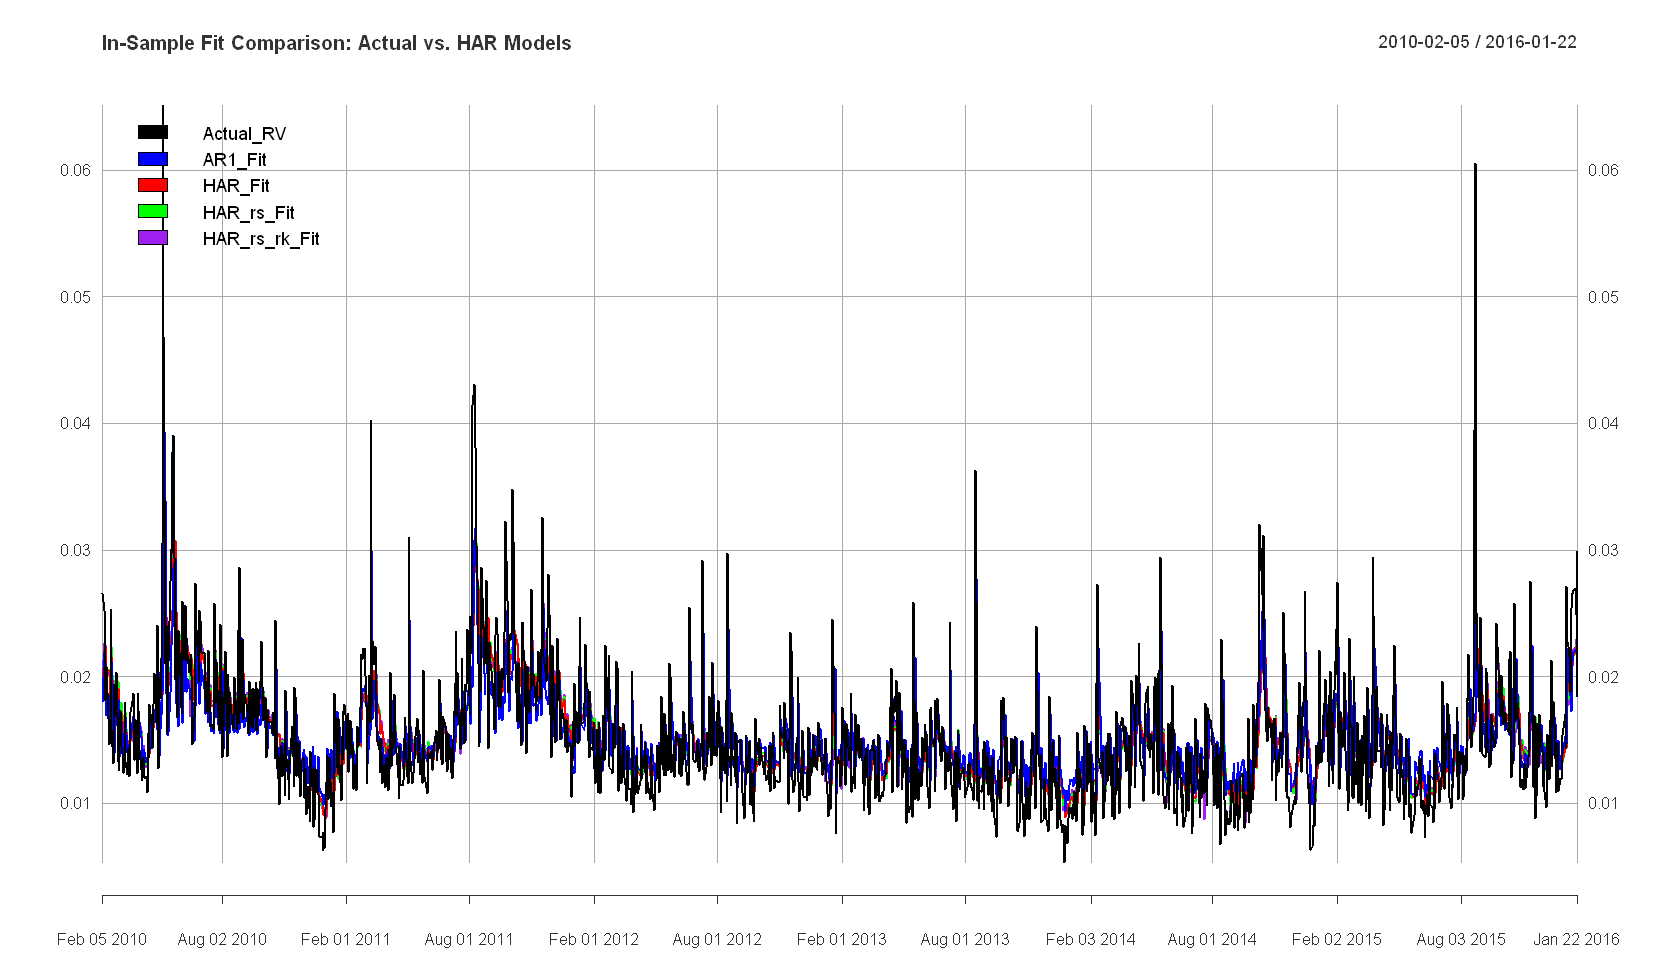

In [17]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison[, c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "blue", "red", "green", "purple"),
         main = "In-Sample Fit Comparison: Actual vs. HAR Models",
         legend.loc = "topleft")

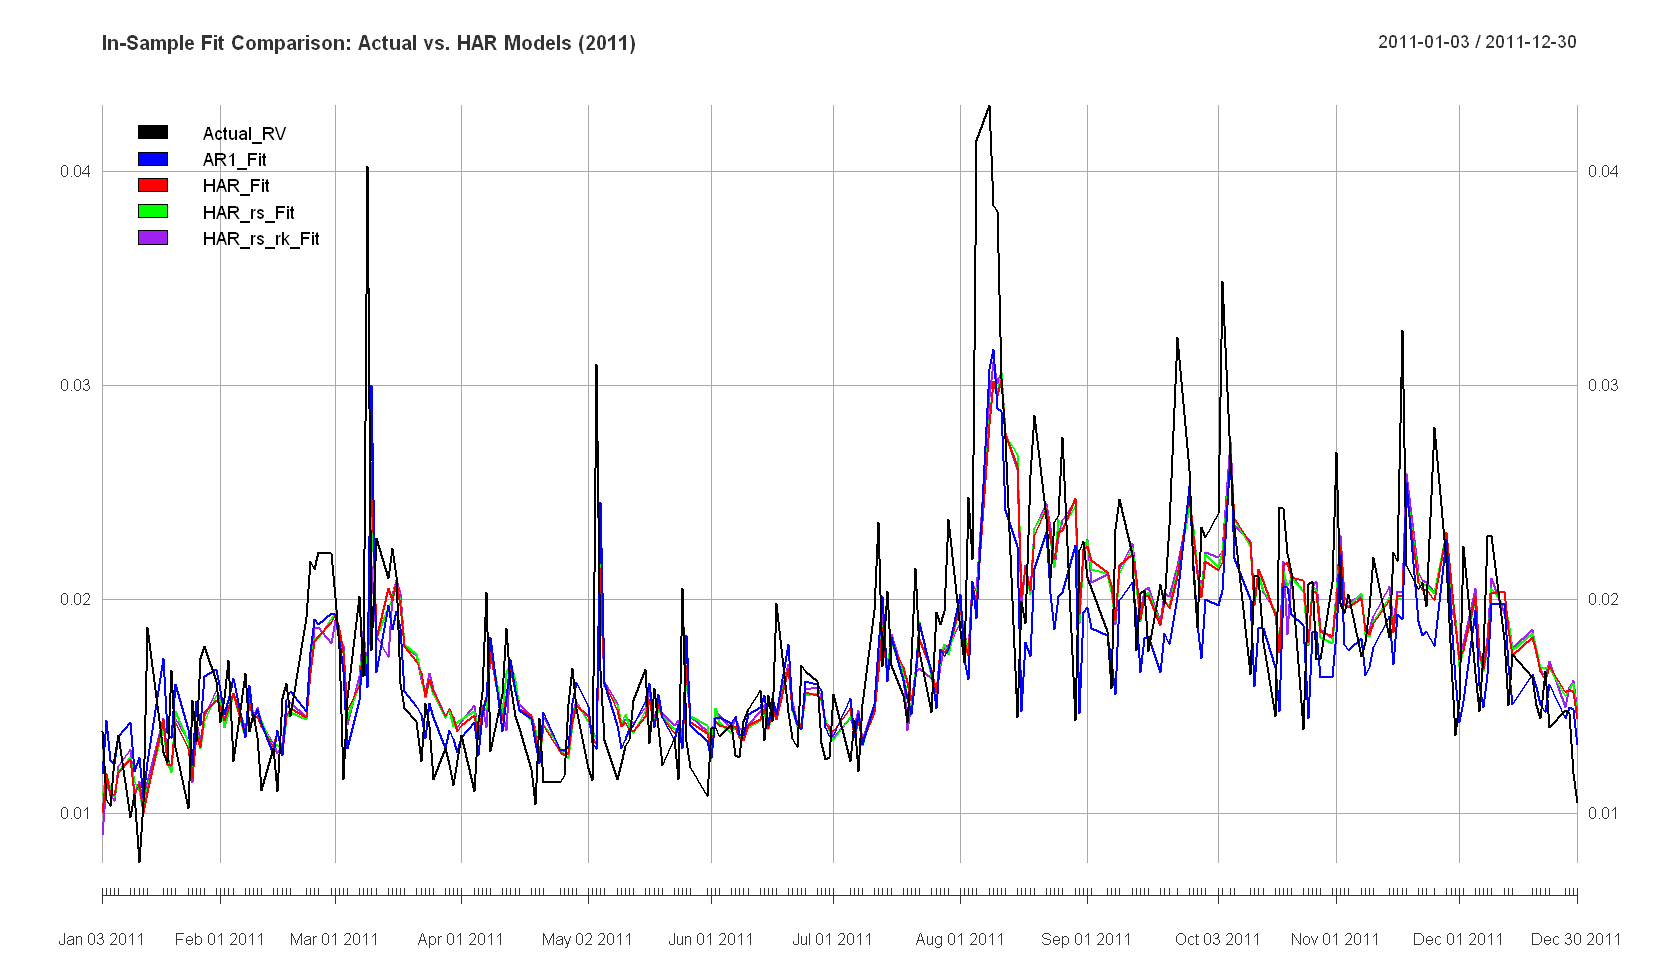

In [18]:
options(repr.plot.width = 14, repr.plot.height = 8)

#zoom in on 2011 for example
plot.xts(na.omit(fit_comparison["2011", c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit")]), 
         screens = 1, 
         col = c("black", "blue", "red", "green", "purple"),
         main = "In-Sample Fit Comparison: Actual vs. HAR Models (2011)",
         legend.loc = "topleft")

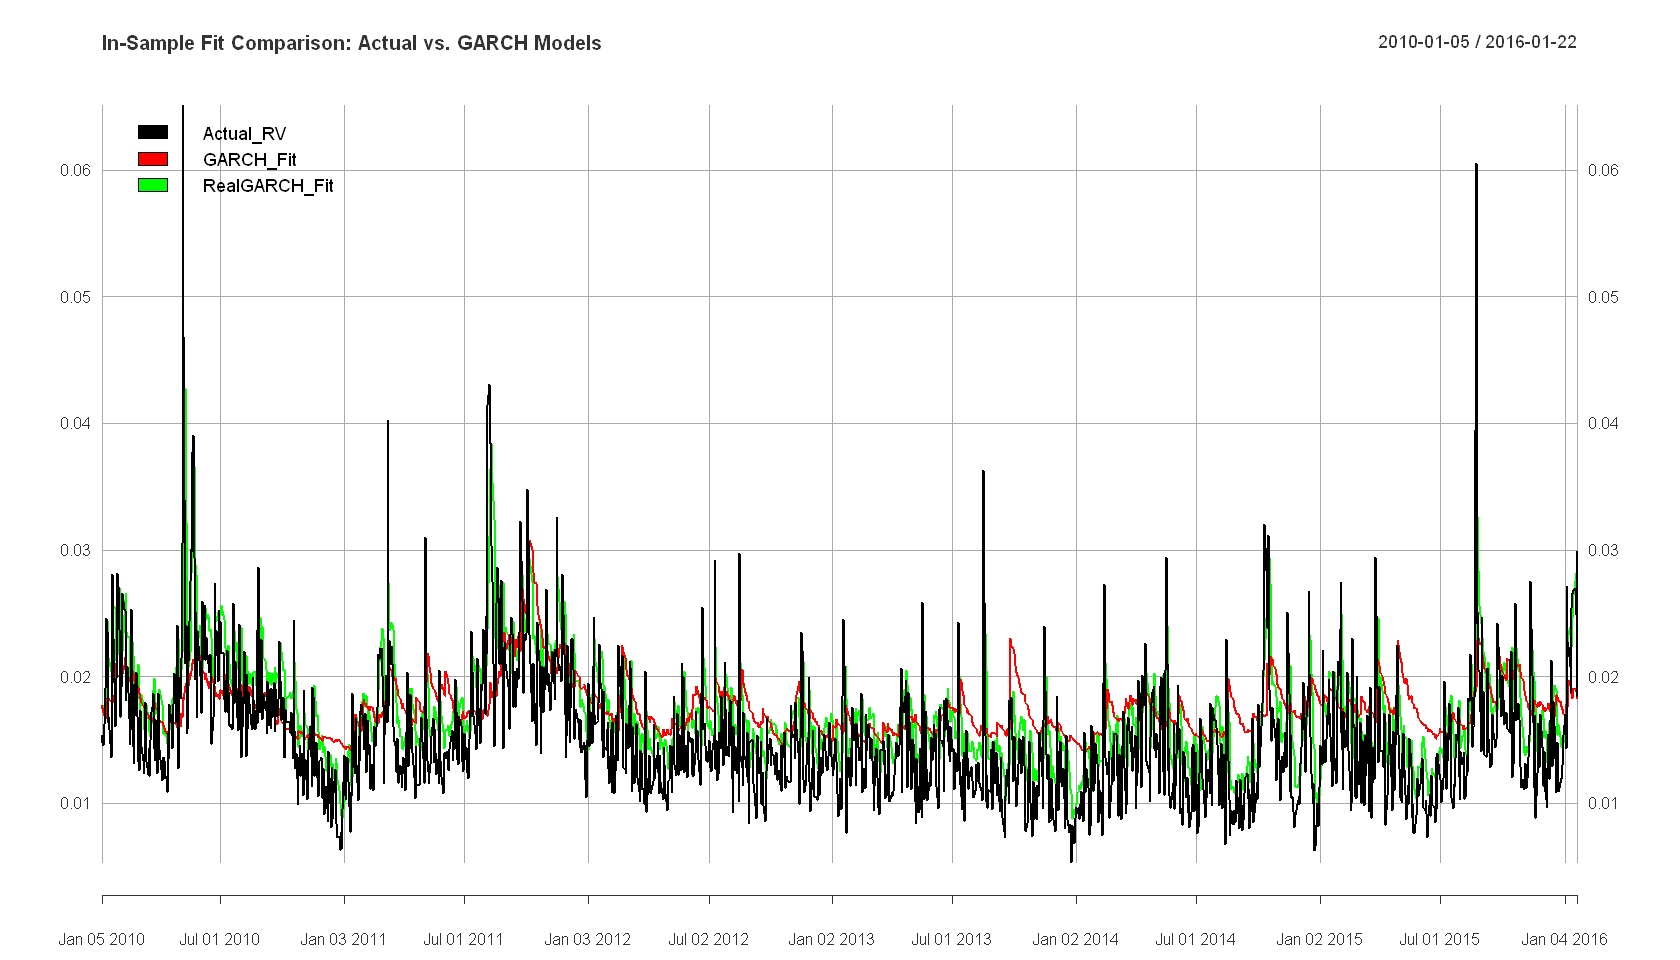

In [19]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison[, c("Actual_RV", "GARCH_Fit", "RealGARCH_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "red", "green"),
         main = "In-Sample Fit Comparison: Actual vs. GARCH Models",
         legend.loc = "topleft")

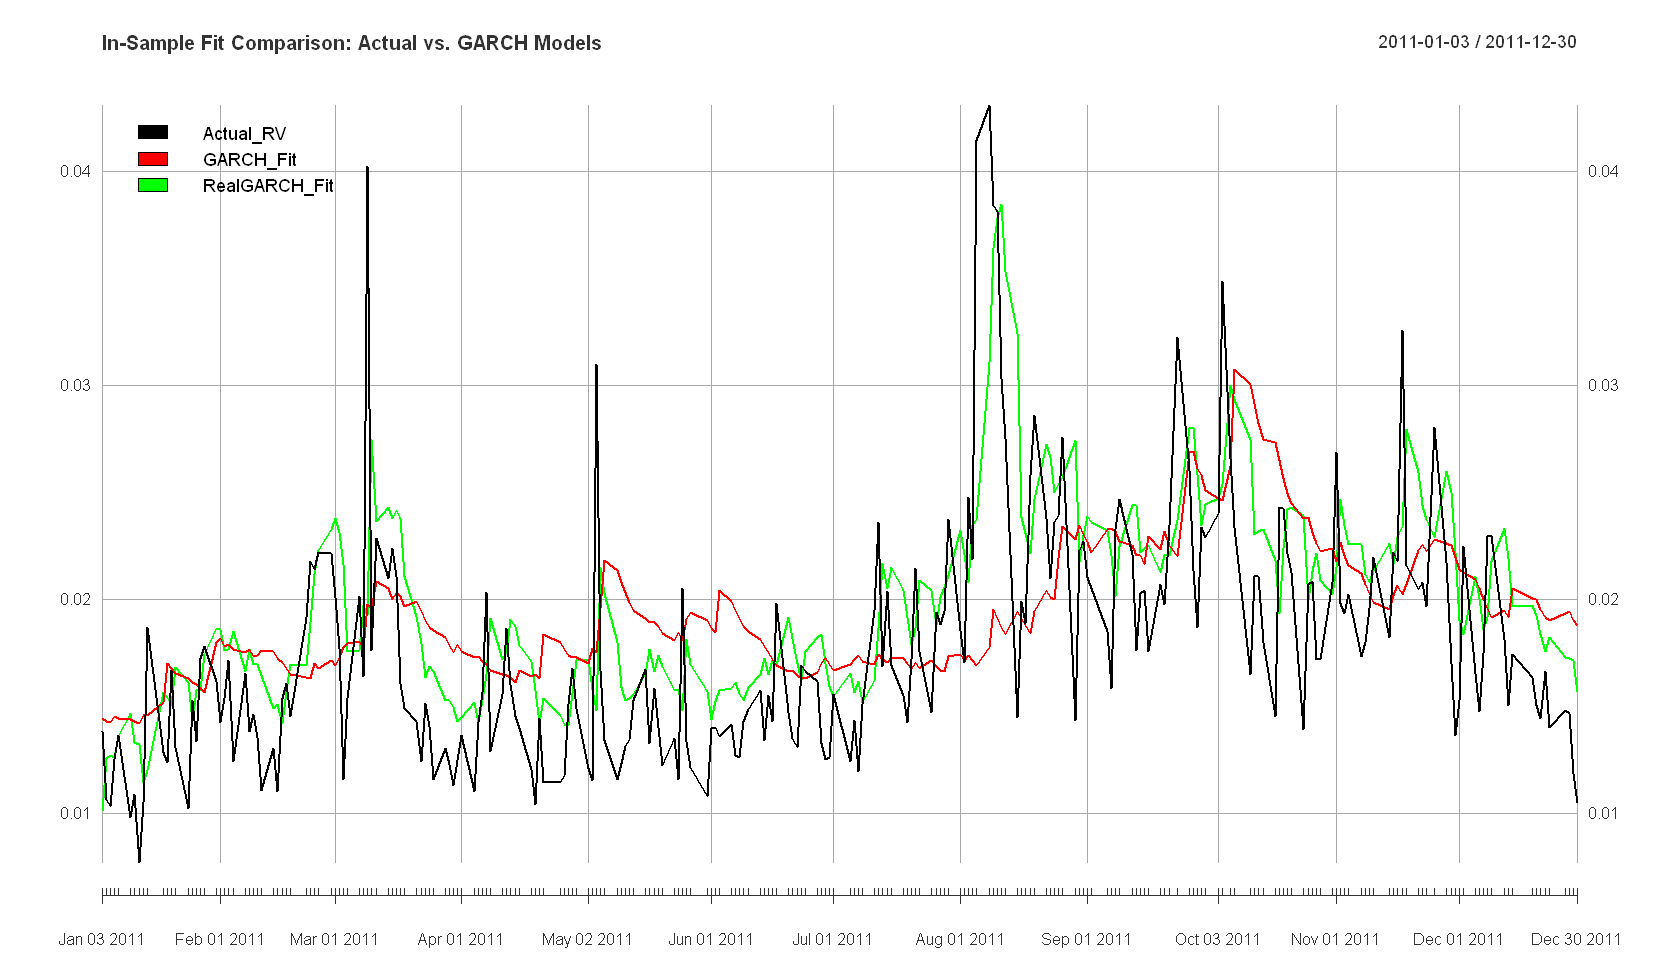

In [20]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison["2011", c("Actual_RV", "GARCH_Fit", "RealGARCH_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "red", "green"),
         main = "In-Sample Fit Comparison: Actual vs. GARCH Models",
         legend.loc = "topleft")

## Forectasts

In [21]:
window_len <- 750
n_obs <- nrow(har_data)
out_sample_len <- n_obs - window_len

In [22]:
fcst_ar1_roll <- numeric(out_sample_len)
fcst_har_roll <- numeric(out_sample_len)
fcst_har_rs_roll <- numeric(out_sample_len)
fcst_har_rs_rk_roll <- numeric(out_sample_len)

fcst_ar1_exp <- numeric(out_sample_len)
fcst_har_exp <- numeric(out_sample_len)
fcst_har_rs_exp <- numeric(out_sample_len)
fcst_har_rs_rk_exp <- numeric(out_sample_len)

# Actual values for the out-of-sample period to compare against
actual_out_sample <- har_data$RV[(window_len + 1):n_obs]

In [23]:
for (i in 1:out_sample_len) {
  
  # Rolling Window 
  train_data_roll <- har_data[i:(window_len + i - 1), ]
  
  # Expanding Window 
  train_data_exp <- har_data[1:(window_len + i - 1), ]
  
  # The row of data we are using to predict tomorrow's RV
  test_data <- har_data[(window_len + i), ]
  
  # --- ROLLING WINDOW FITS & FORECASTS ---
  fit_ar1_roll <- lm(RV ~ RV_1, data = train_data_roll)
  fit_har_roll <- lm(RV ~ RV_1 + RV_5 + RV_22, data = train_data_roll)
  fit_har_rs_roll <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = train_data_roll)
  fit_har_rs_rk_roll <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = train_data_roll)
    
  fcst_ar1_roll[i] <- predict(fit_ar1_roll, newdata = test_data)
  fcst_har_roll[i] <- predict(fit_har_roll, newdata = test_data)
  fcst_har_rs_roll[i] <- predict(fit_har_rs_roll, newdata = test_data)  
  fcst_har_rs_rk_roll[i] <- predict(fit_har_rs_rk_roll, newdata = test_data) 
    
  # --- EXPANDING WINDOW FITS & FORECASTS ---
  fit_ar1_exp <- lm(RV ~ RV_1, data = train_data_exp)
  fit_har_exp <- lm(RV ~ RV_1 + RV_5 + RV_22, data = train_data_exp)
  fit_har_rs_exp <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = train_data_exp)
  fit_har_rs_rk_exp <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = train_data_exp)
    
  fcst_ar1_exp[i] <- predict(fit_ar1_exp, newdata = test_data)
  fcst_har_exp[i] <- predict(fit_har_exp, newdata = test_data)
  fcst_har_rs_exp[i] <- predict(fit_har_rs_exp, newdata = test_data)  
  fcst_har_rs_rk_exp[i] <- predict(fit_har_rs_rk_exp, newdata = test_data)   
}

following cell does not work

In [24]:
#garch_roll <- ugarchroll(spec_garch, data = asset_data$ret, 
#                         n.start = window_len, refit.every = 1, refit.window = "moving")
#garch_exp  <- ugarchroll(spec_garch, data = asset_data$ret, 
#                         n.start = window_len, refit.every = 1, refit.window = "recursive")
#
#fcst_garch_roll <- garch_roll@forecast$density[,"Sigma"]
#fcst_garch_exp  <- garch_exp@forecast$density[,"Sigma"]
#
# Realized GARCH (passing the realizedVol argument), REFIT 5 or 1? recalculate for every day or week? mostly bcs of computation
#realGARCH_roll <- ugarchroll(spec_real, data = asset_data$ret, realizedVol = asset_data$RV,
#                             n.start = window_len, refit.every = 5, refit.window = "moving", solver = "hybrid")
#realGARCH_exp  <- ugarchroll(spec_real, data = asset_data$ret, realizedVol = asset_data$RV,
#                             n.start = window_len, refit.every = 5, refit.window = "recursive", solver = "hybrid")
#
#fcst_realGARCH_roll <- realGARCH_roll@forecast$density[,"Sigma"]
#fcst_realGARCH_exp  <- realGARCH_exp@forecast$density[,"Sigma"]

In [25]:
# Helper function to calculate MSE and MAE
calc_loss <- function(actual, forecast) {
  error <- actual - forecast
  mse <- mean(error^2, na.rm = TRUE)
  mae <- mean(abs(error), na.rm = TRUE)
  return(c(MSE = mse, MAE = mae))
}

In [26]:
results_matrix <- rbind(
  calc_loss(actual_out_sample, fcst_ar1_roll),
  calc_loss(actual_out_sample, fcst_har_roll),
  calc_loss(actual_out_sample, fcst_har_rs_roll),
  calc_loss(actual_out_sample, fcst_har_rs_rk_roll),
  calc_loss(actual_out_sample, fcst_ar1_exp),
  calc_loss(actual_out_sample, fcst_har_exp),
  calc_loss(actual_out_sample, fcst_har_rs_exp),
  calc_loss(actual_out_sample, fcst_har_rs_rk_exp)
)

rownames(results_matrix) <- c(
  "AR1 (Roll)", "HAR (Roll)", "HAR-RS (Roll)", "HAR-RS-RK (Roll)",
  "AR1 (Exp)", "HAR (Exp)", "HAR-RS (Exp)", "HAR-RS-RK (Exp)"
)

In [27]:
cat("--- OUT-OF-SAMPLE FORECAST EVALUATION ---\n")
print(round(results_matrix, 7))

--- OUT-OF-SAMPLE FORECAST EVALUATION ---
                      MSE       MAE
AR1 (Roll)       1.72e-05 0.0028961
HAR (Roll)       1.60e-05 0.0027697
HAR-RS (Roll)    1.60e-05 0.0027680
HAR-RS-RK (Roll) 1.57e-05 0.0027614
AR1 (Exp)        1.72e-05 0.0029373
HAR (Exp)        1.58e-05 0.0027763
HAR-RS (Exp)     1.57e-05 0.0027720
HAR-RS-RK (Exp)  1.54e-05 0.0027632


In [28]:
err_ar1_roll       <- actual_out_sample - fcst_ar1_roll
err_har_roll       <- actual_out_sample - fcst_har_roll
err_har_rs_roll    <- actual_out_sample - fcst_har_rs_roll
err_har_rs_rk_roll <- actual_out_sample - fcst_har_rs_rk_roll
err_ar1_exp       <- actual_out_sample - fcst_ar1_exp
err_har_exp       <- actual_out_sample - fcst_har_exp
err_har_rs_exp    <- actual_out_sample - fcst_har_rs_exp
err_har_rs_rk_exp <- actual_out_sample - fcst_har_rs_rk_exp

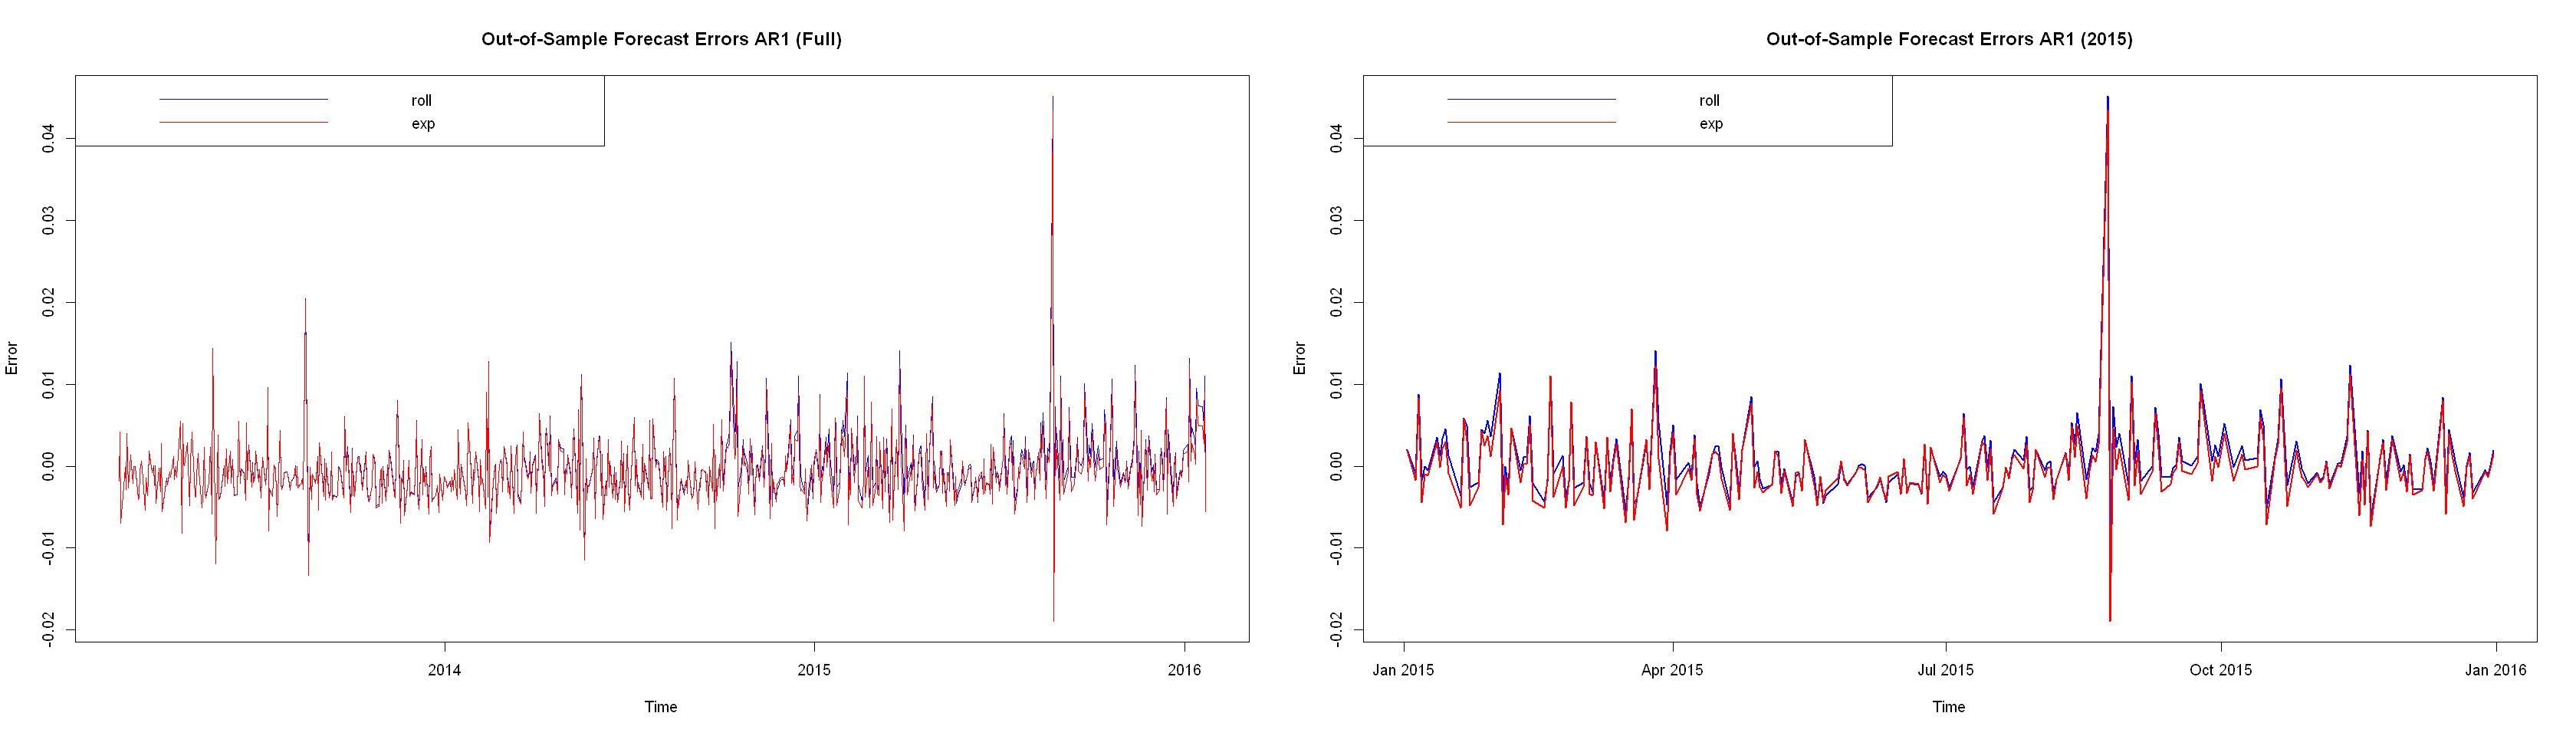

In [29]:
options(repr.plot.width = 28, repr.plot.height = 8)
  
# 1. Prepare your data
ar1_errors <- merge(err_ar1_roll, err_ar1_exp)
ar1_errors_2015 <- ar1_errors["2015"] # Create the 2014 subset
  
# 2. Split the plotting window into 1 row, 2 columns
par(mfrow = c(1, 2))
  
# 3. Plot 1: Full dataset (Left Side)
zoo::plot.zoo(ar1_errors, plot.type = "single", 
            col = c("blue", "red"),lwd = 1.5,
            main = "Out-of-Sample Forecast Errors AR1 (Full)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)
  
# 4. Plot 2: 2014 dataset only (Right Side)
zoo::plot.zoo(ar1_errors_2015, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,
            main = "Out-of-Sample Forecast Errors AR1 (2015)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)

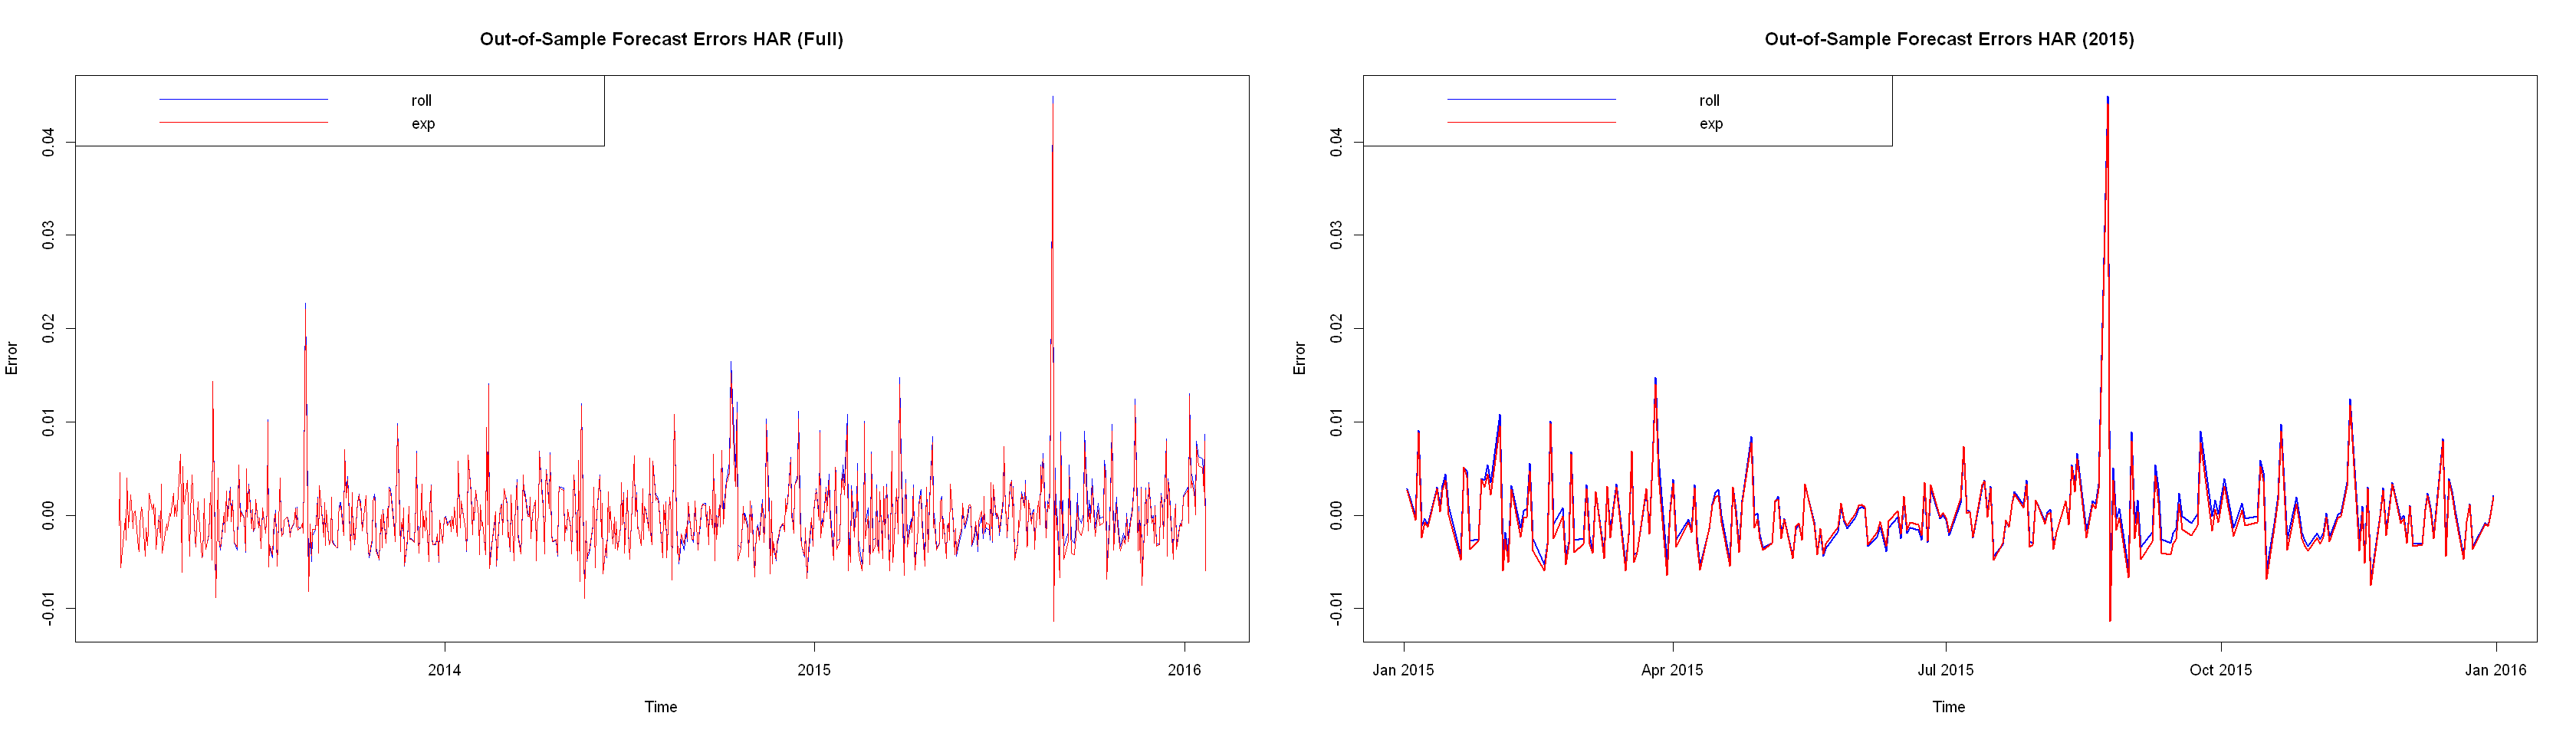

In [30]:
options(repr.plot.width = 28, repr.plot.height = 8)
  
# 1. Prepare your data
har_errors <- merge(err_har_roll, err_har_exp)
har_errors_2015 <- har_errors["2015"] # Create the 2014 subset
  
# 2. Split the plotting window into 1 row, 2 columns
par(mfrow = c(1, 2))
  
# 3. Plot 1: Full dataset (Left Side)
zoo::plot.zoo(har_errors, plot.type = "single", 
            col = c("blue", "red"),lwd = 1.5,
            main = "Out-of-Sample Forecast Errors HAR (Full)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)
  
# 4. Plot 2: 2014 dataset only (Right Side)
zoo::plot.zoo(har_errors_2015, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,
            main = "Out-of-Sample Forecast Errors HAR (2015)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)

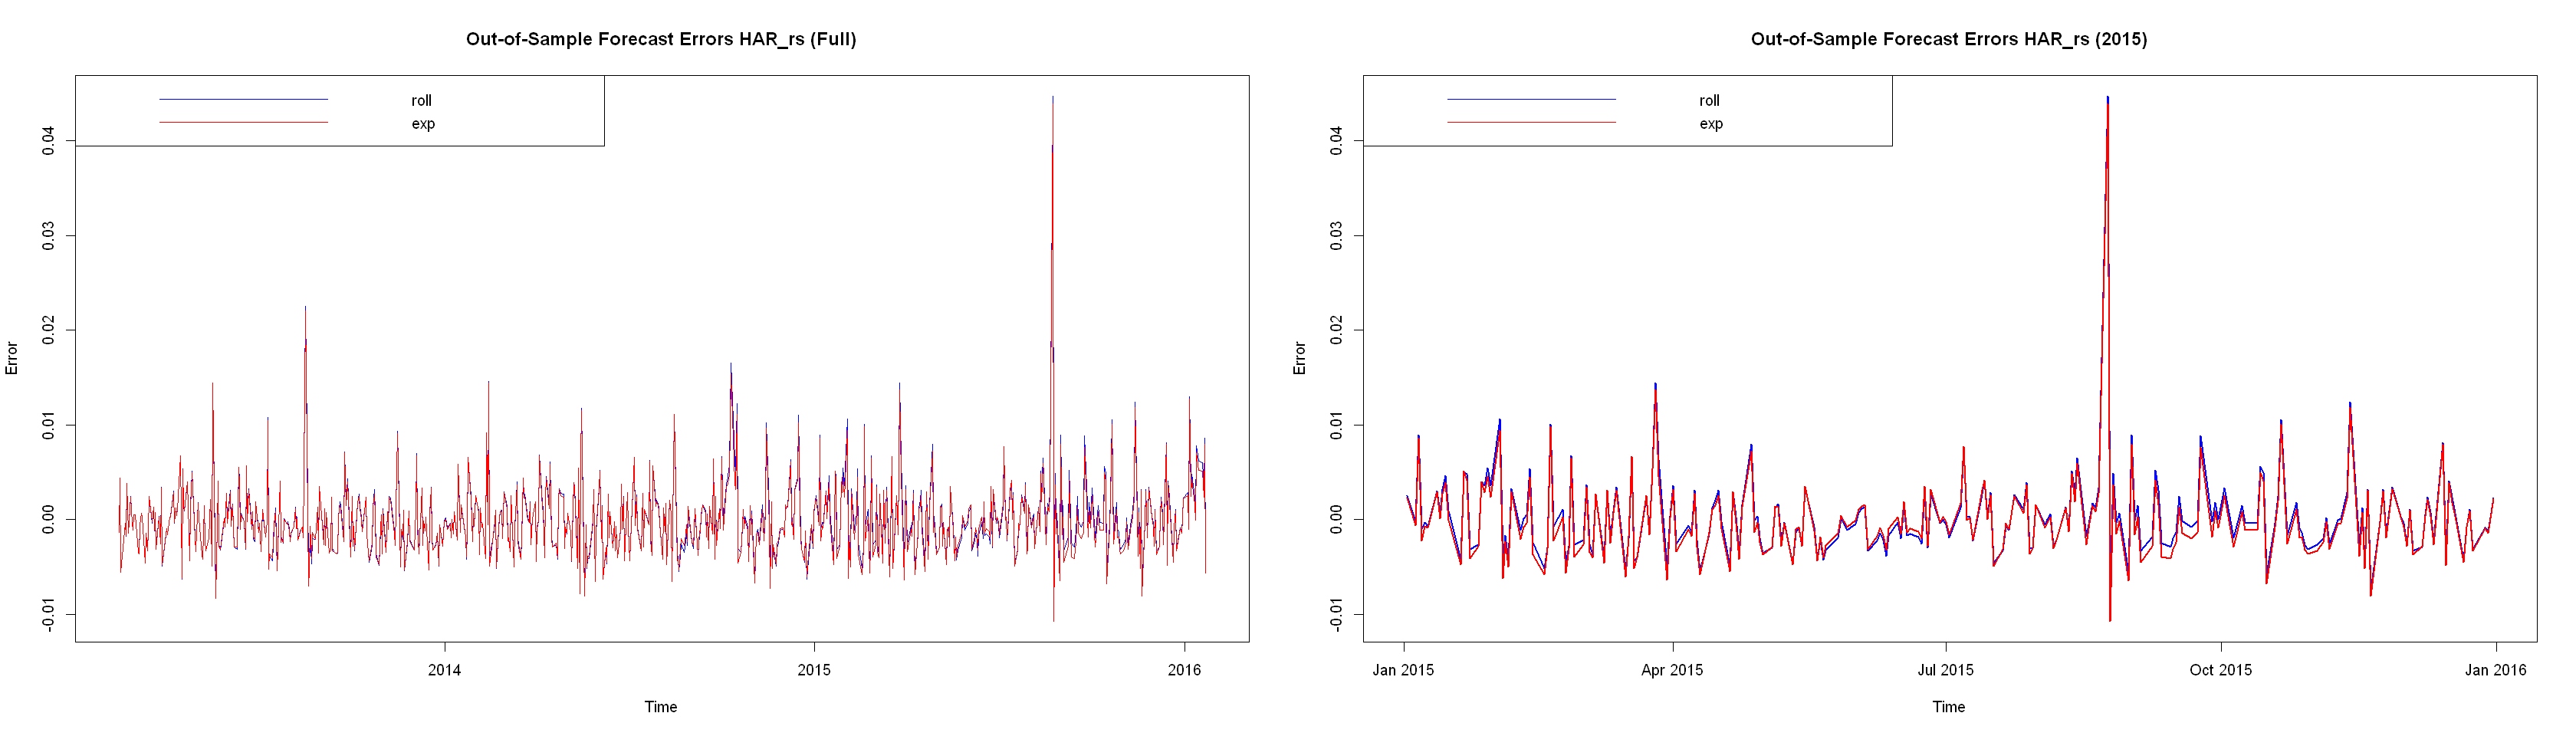

In [31]:
options(repr.plot.width = 28, repr.plot.height = 8)
 
# 1. Prepare your data
har_rs_errors <- merge(err_har_rs_roll, err_har_rs_exp)
har_rs_errors_2015 <- har_rs_errors["2015"] # Create the 2014 subset
  
# 2. Split the plotting window into 1 row, 2 columns
par(mfrow = c(1, 2))
  
# 3. Plot 1: Full dataset (Left Side)
zoo::plot.zoo(har_rs_errors, plot.type = "single", 
            col = c("blue", "red"),lwd = 1.5,
            main = "Out-of-Sample Forecast Errors HAR_rs (Full)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)
  
# 4. Plot 2: 2014 dataset only (Right Side)
zoo::plot.zoo(har_rs_errors_2015, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,
            main = "Out-of-Sample Forecast Errors HAR_rs (2015)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1,bg = adjustcolor("white", alpha.f = 0.7))

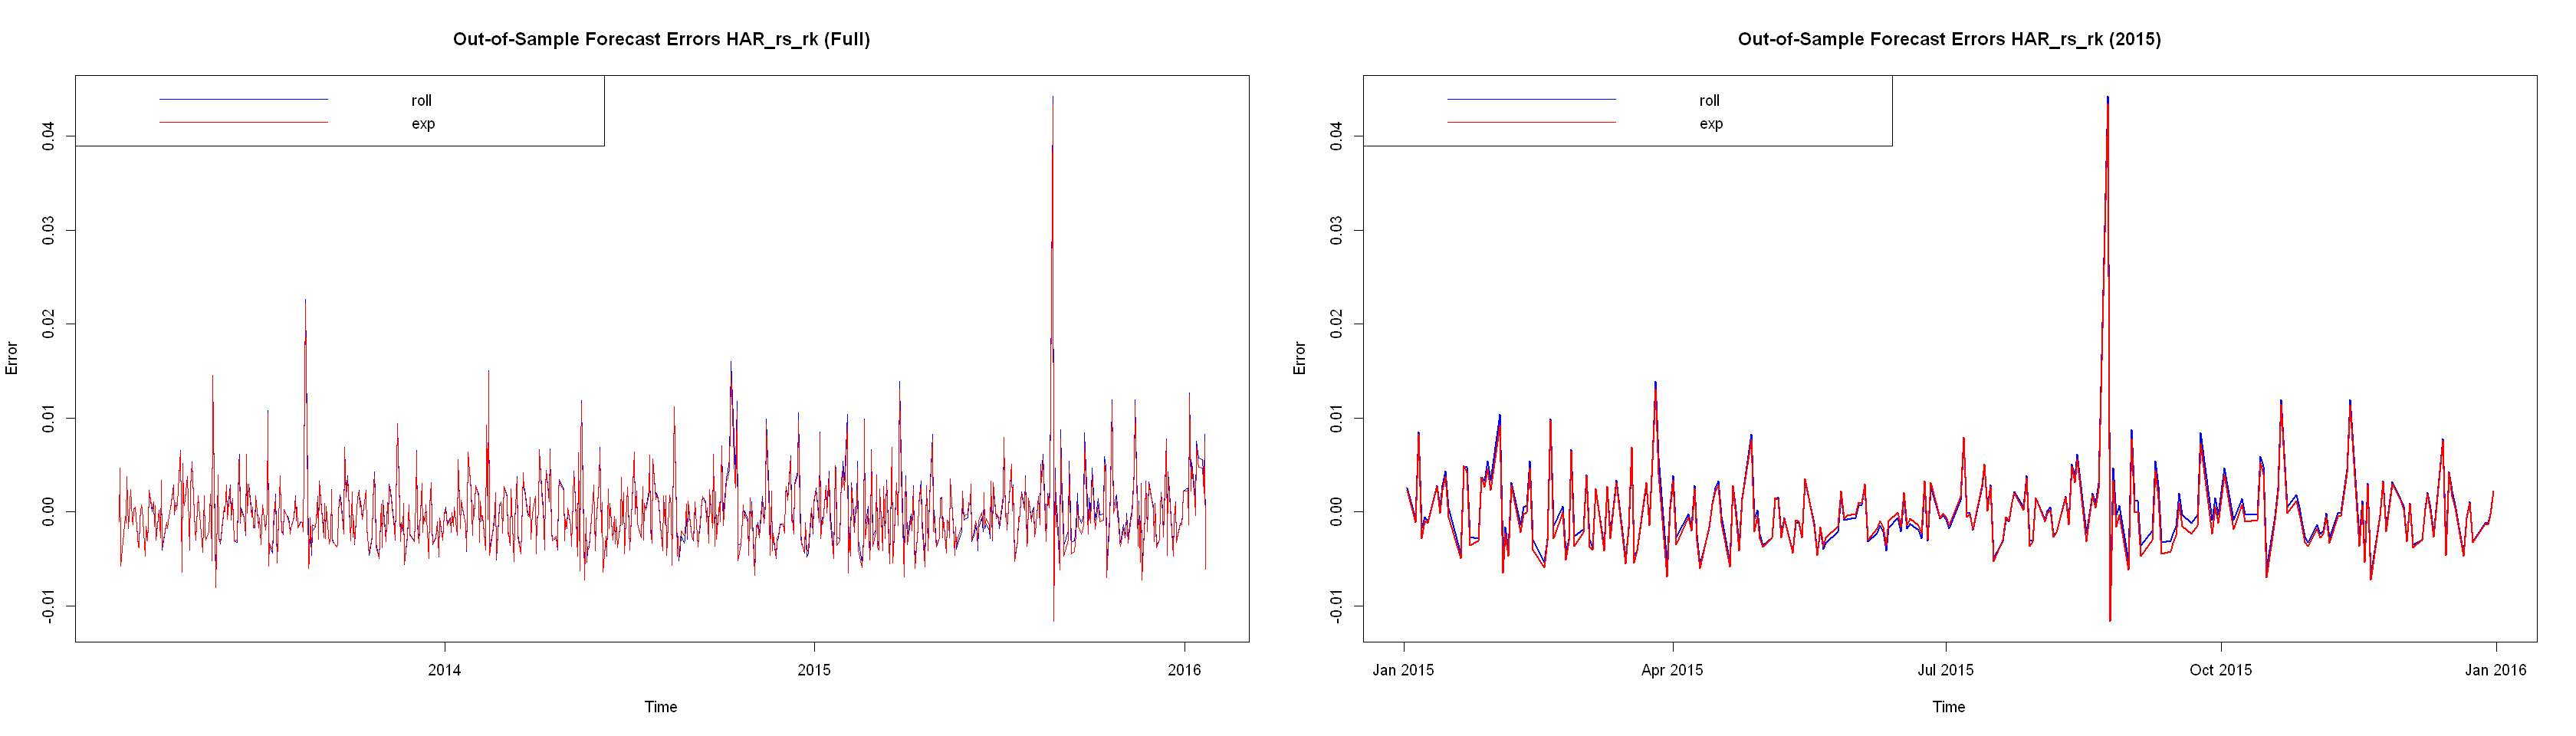

In [32]:
options(repr.plot.width = 28, repr.plot.height = 8)
 
# 1. Prepare your data
har_rs_rk_errors <- merge(err_har_rs_rk_roll, err_har_rs_rk_exp)
har_rs_rk_errors_2015 <- har_rs_rk_errors["2015"] # Create the 2014 subset
  
# 2. Split the plotting window into 1 row, 2 columns
par(mfrow = c(1, 2))
  
# 3. Plot 1: Full dataset (Left Side)
zoo::plot.zoo(har_rs_rk_errors, plot.type = "single", 
            col = c("blue", "red"),lwd = 1.5,
            main = "Out-of-Sample Forecast Errors HAR_rs_rk (Full)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)
  
# 4. Plot 2: 2014 dataset only (Right Side)
zoo::plot.zoo(har_rs_rk_errors_2015, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,
            main = "Out-of-Sample Forecast Errors HAR_rs_rk (2015)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1,bg = adjustcolor("white", alpha.f = 0.7))

In [33]:
all_errors_roll <- merge(err_ar1_roll, err_har_roll, err_har_rs_roll,err_har_rs_rk_roll)
all_errors_exp <- merge(err_ar1_exp, err_har_exp, err_har_rs_exp, err_har_rs_rk_exp)

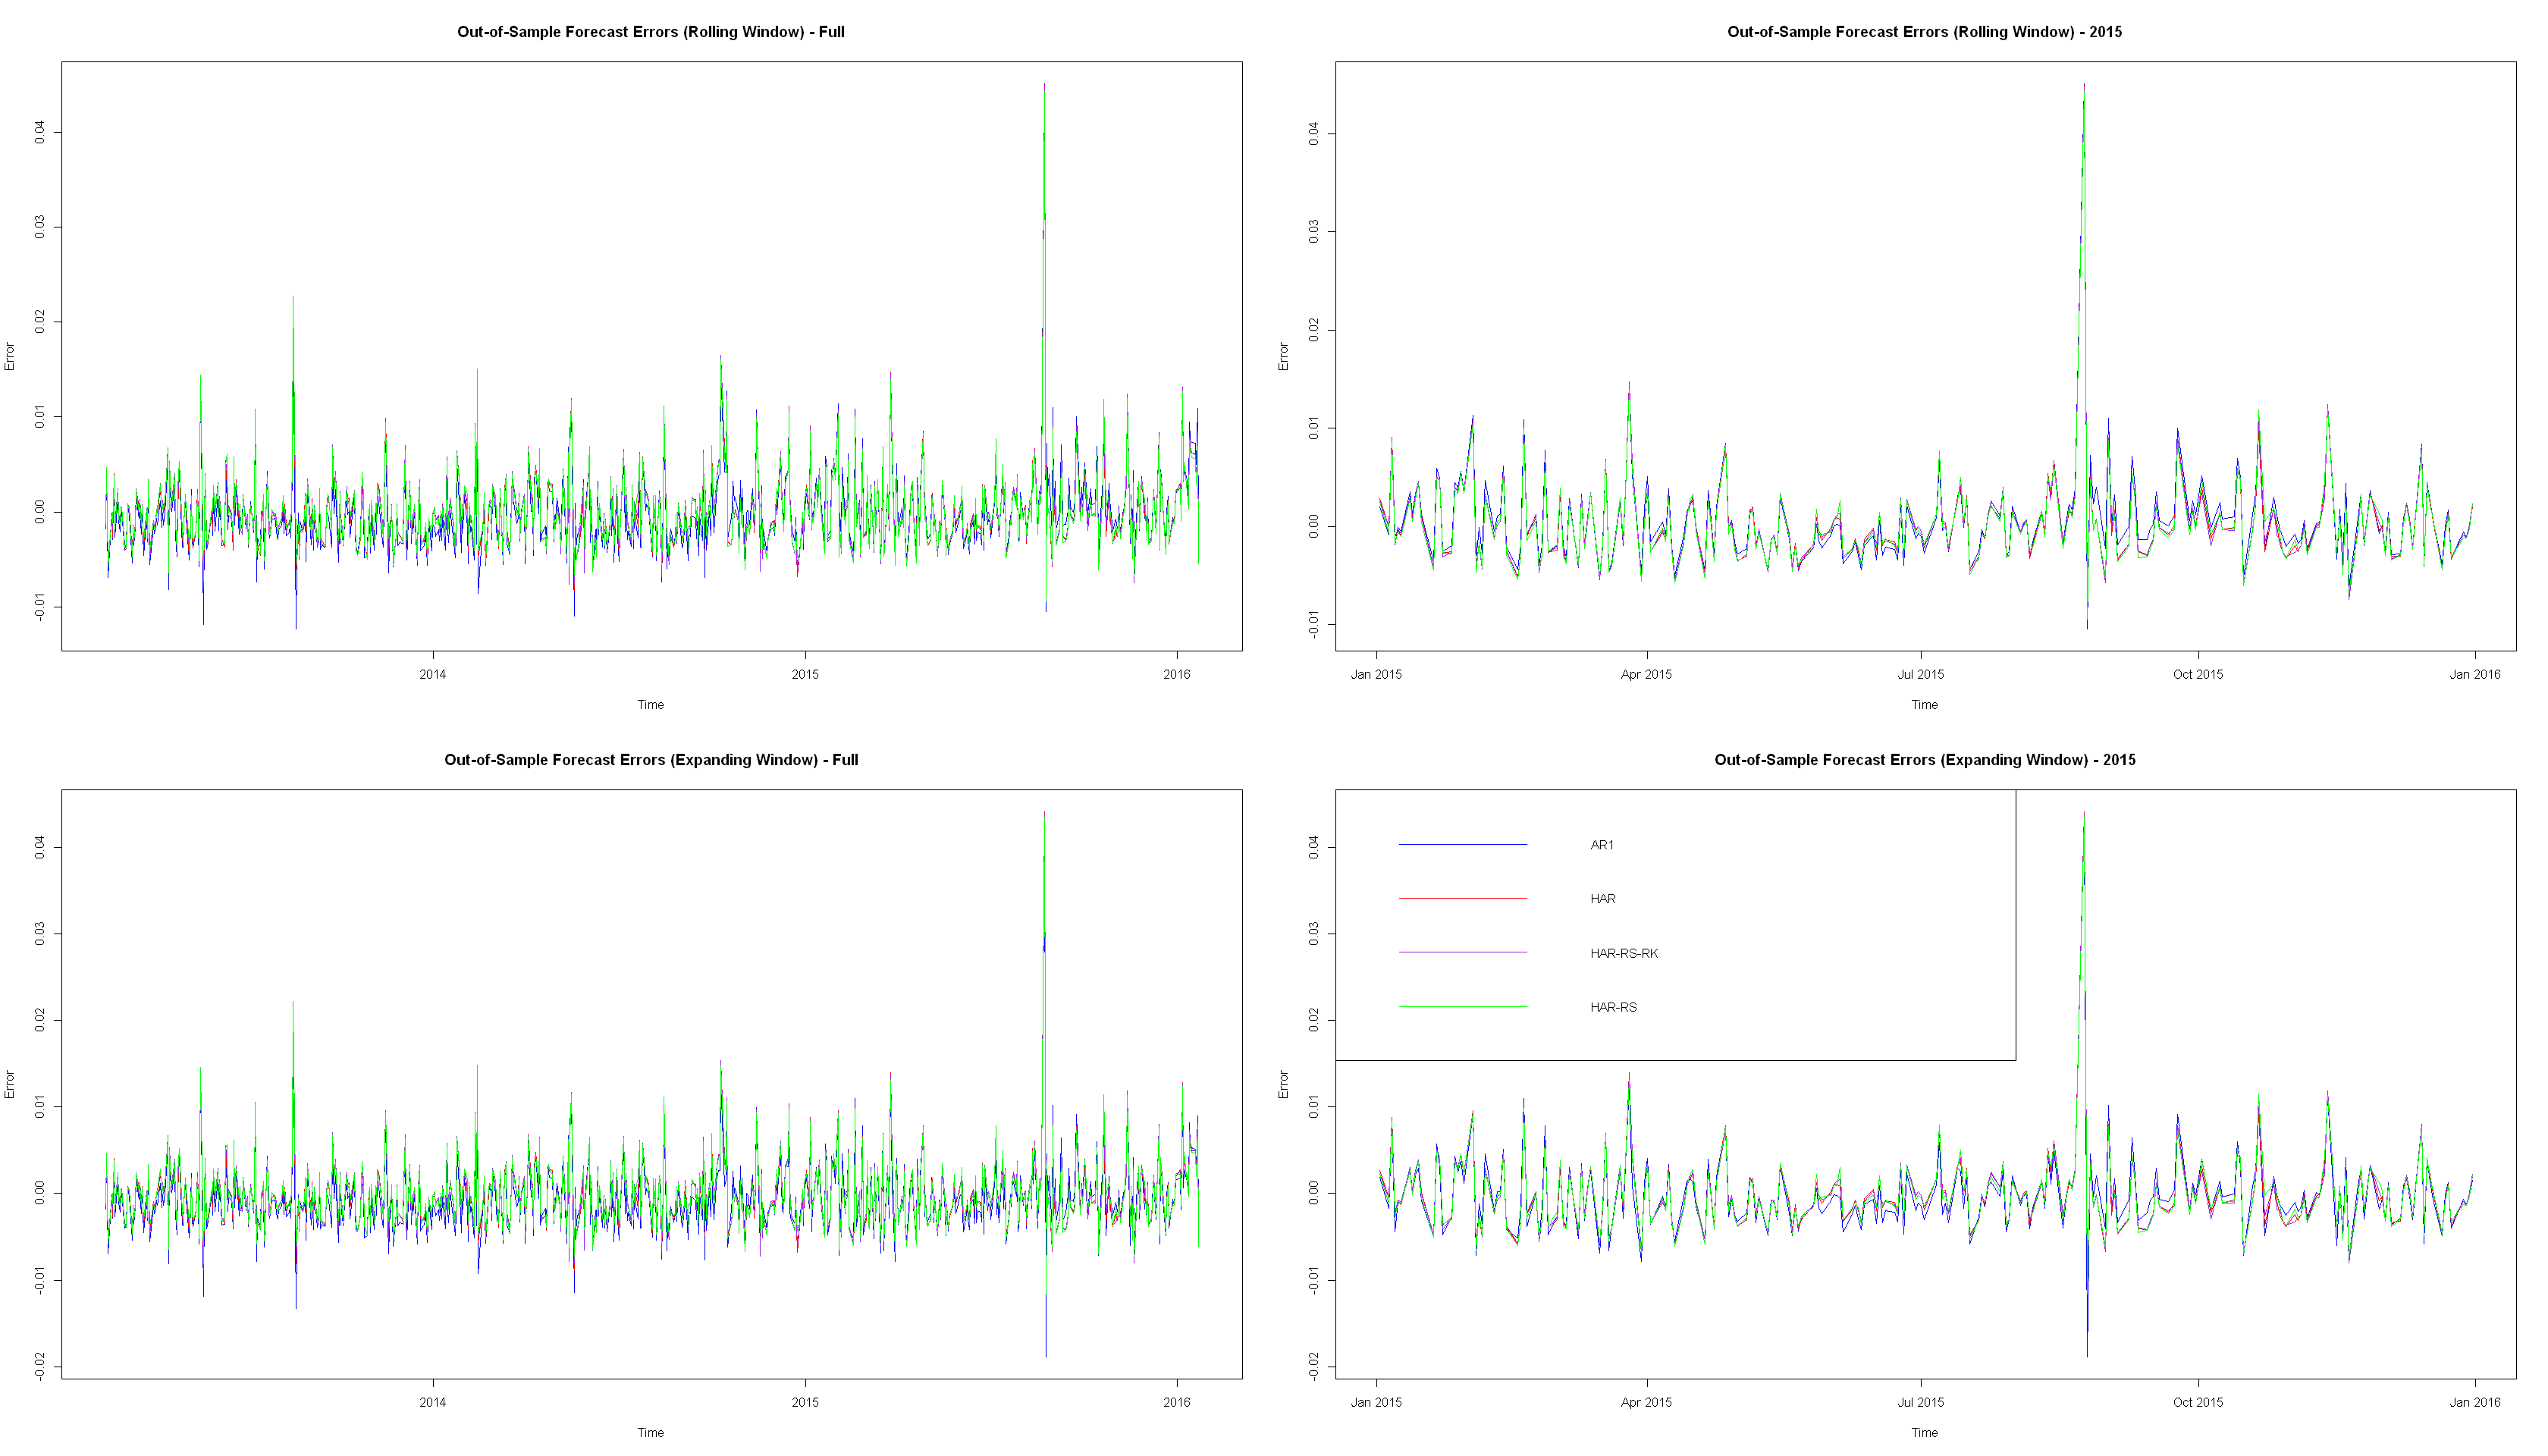

In [41]:
all_errors_roll_2015 <- all_errors_roll["2015"]
all_errors_exp_2015 <- all_errors_exp["2015"]
options(repr.plot.width = 28, repr.plot.height = 16)
par(mfrow = c(2, 2))
# plot.zoo with plot.type="single" elegantly plots all columns at once
zoo::plot.zoo(all_errors_roll, plot.type = "single", 
            col = c("blue", "red", "purple", "green"),lwd=1,
            main = "Out-of-Sample Forecast Errors (Rolling Window) - Full", 
            ylab = "Error", xlab = "Time")

zoo::plot.zoo(all_errors_roll_2015, plot.type = "single", 
            col = c("blue", "red", "purple", "green"),lwd=1,
            main = "Out-of-Sample Forecast Errors (Rolling Window) - 2015", 
            ylab = "Error", xlab = "Time")

zoo::plot.zoo(all_errors_exp, plot.type = "single", 
            col = c("blue", "red", "purple", "green"),lwd=1,
            main = "Out-of-Sample Forecast Errors (Expanding Window) - Full", 
            ylab = "Error", xlab = "Time")

zoo::plot.zoo(all_errors_exp_2015, plot.type = "single", 
            col = c("blue", "red", "purple", "green"),lwd=1,
            main = "Out-of-Sample Forecast Errors (Expanding Window) - 2015", 
            ylab = "Error", xlab = "Time")
# Add the legend
legend("topleft", legend = c("AR1", "HAR", "HAR-RS-RK", "HAR-RS"), 
        col = c("blue", "red", "purple", "green"), lty = 1)


In [42]:
# 1. Diebold-Mariano Test (Comparing models against the baseline HAR model)
cat("\n--- DIEBOLD-MARIANO TESTS (vs HAR Rolling) ---\n")
print(dm.test(err_har_roll, err_ar1_roll, alternative = "two.sided", power = 2))
print(dm.test(err_har_roll, err_har_rs_rk_roll, alternative = "two.sided", power = 2))
print(dm.test(err_har_roll, err_har_rs_roll, alternative = "two.sided", power = 2))


--- DIEBOLD-MARIANO TESTS (vs HAR Rolling) ---

	Diebold-Mariano Test

data:  err_har_rollerr_ar1_roll
DM = -3.2122, Forecast horizon = 1, Loss function power = 2, p-value =
0.001375
alternative hypothesis: two.sided


	Diebold-Mariano Test

data:  err_har_rollerr_har_rs_rk_roll
DM = 1.9168, Forecast horizon = 1, Loss function power = 2, p-value =
0.05566
alternative hypothesis: two.sided


	Diebold-Mariano Test

data:  err_har_rollerr_har_rs_roll
DM = 0.45786, Forecast horizon = 1, Loss function power = 2, p-value =
0.6472
alternative hypothesis: two.sided

